# Analysis of Community Detection Algorithms

This notebook provides a detailed analysis of the results from a comparative study of community detection algorithms. We will explore the performance of traditional methods (Louvain, Label Propagation, Girvan-Newman) and Graph Neural Network (GNN) based models (GCN, GraphSAGE) across several standard graph datasets.

The analysis is structured as follows:
1. **Dataset Characteristics**: A look at the properties of the datasets used.
2. **Understanding the Metrics**: An explanation of each evaluation metric, its value range, and its optimization goal.
3. **Results Visualization**: Visual comparison of the algorithms' performance on each dataset using bar plots.
4. **Discussion of Results**: A summary and interpretation of the key findings from the experiments.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
sns.set_theme(style="whitegrid", palette="magma")

## 1. Dataset Characteristics

First, let's understand the datasets we are working with. The properties of a graph can significantly influence the performance of community detection algorithms. For instance, GNNs typically require node features to learn meaningful representations, whereas traditional methods operate purely on the graph's topology.

In [22]:
from torch_geometric.datasets import KarateClub, Planetoid
from torch_geometric.utils import to_undirected
from deep_learning_methods import get_cora_subgraph_pyg
# Load datasets (adjust paths as needed)
karate_data = KarateClub()[0]
cora_data = Planetoid(root='/tmp/Cora', name='Cora')[0]
pubmed_data = Planetoid(root='/tmp/PubMed', name='PubMed')[0]


cora_subset_data = get_cora_subgraph_pyg(cora_data)

datasets = {
    'KarateClub': karate_data,
    'Cora_Subset': cora_subset_data,
    'Cora': cora_data,
    'PubMed': pubmed_data
}

stats = {
    'Dataset': [],
    'Nodes': [],
    'Edges': [],
    'Avg. Node Degree': [],
    'Node Feature Dim.': [],
    '# Classes / GT Communities': []
}

for name, data in datasets.items():
    num_nodes = data.num_nodes
    edge_index = to_undirected(data.edge_index)
    num_edges = edge_index.size(1) // 2
    avg_degree = (2 * num_edges) / num_nodes
    feat_dim = data.x.size(1) if data.x is not None else 0
    num_classes = int(data.y.max().item() + 1) if data.y is not None else 0

    stats['Dataset'].append(name)
    stats['Nodes'].append(num_nodes)
    stats['Edges'].append(num_edges)
    stats['Avg. Node Degree'].append(round(avg_degree, 2))
    stats['Node Feature Dim.'].append(feat_dim)
    stats['# Classes / GT Communities'].append(num_classes)

stats_df = pd.DataFrame(stats)
stats_df.set_index('Dataset')

Created PyG Cora subgraph with 150 nodes and 256 edges.


,Nodes,Edges,Avg. Node Degree,Node Feature Dim.,# Classes / GT Communities
Dataset,,,,,
KarateClub,34,78,4.59,34,4
Cora_Subset,150,256,3.41,1433,7
Cora,2708,5278,3.90,1433,7
PubMed,19717,44324,4.50,500,3


The KarateClub dataset is very small (34 nodes) and lacks high-dimensional node features, which may explain why GNNs don't show a clear advantage and can sometimes perform poorly (like GraphSage's negative modularity). In contrast, Cora and PubMed are much larger and have rich node features, providing a better playground for GNNs to learn effective node embeddings for community detection.

## 2. Understanding the Metrics

To interpret the results correctly, we need to understand what each metric measures. The metrics are divided into two categories: internal and external.

### Internal Metrics
These metrics evaluate the quality of a partition based only on the graph's structure, without any ground-truth information.

- **Modularity**: 
  - **What it is**: Measures the density of edges inside communities as compared to edges between communities. It quantifies how well a partitioning separates the graph into dense, well-defined clusters.
  - **Range**: `[-0.5, 1]`. Values closer to 1 indicate strong community structure.
  - **Goal**: **Maximize**.

- **Average Conductance**:
  - **What it is**: Measures the "cut" quality of the communities. For each community, it calculates the ratio of edges pointing outside the community to the total number of edges connected to it. A lower conductance means the community is well-isolated.
  - **Range**: `[0, 1]`. 
  - **Goal**: **Minimize**. A lower average conductance is better.

### External Metrics
These metrics compare the detected communities to the ground-truth labels.

- **Normalized Mutual Information (NMI)**:
  - **What it is**: An information-theoretic metric that measures the similarity between two sets of clusters (the predicted and the true ones). It corrects for chance, so a score of 0 means the similarity is what you'd expect by random chance.
  - **Range**: `[0, 1]`.
  - **Goal**: **Maximize**. A score of 1 indicates a perfect match.

- **Adjusted Rand Score (ARI)**:
  - **What it is**: Measures the similarity between two partitions, correcting for chance. It considers all pairs of nodes and counts pairs that are assigned in the same or different communities in both the predicted and true partitions.
  - **Range**: `[-1, 1]`. Negative values indicate disagreement, 0 is for random labeling, and 1 is a perfect match.
  - **Goal**: **Maximize**.

- **Fowlkes-Mallows Score (FMS)**:
  - **What it is**: The geometric mean of precision and recall. It measures the similarity of the clustering results by considering the number of pairs of points that are in the same cluster in both the true and predicted partitions.
  - **Range**: `[0, 1]`.
  - **Goal**: **Maximize**.

## 3. Results Visualization

Now, let's load the results and visualize them as your friend suggested. We will create a separate plot for each dataset, with bar plots comparing the algorithms across the different metrics. We will handle `Avg_Conductance` separately since its optimization direction is different.

In [23]:
from io import StringIO

with open('community_detection_results.md', 'r') as f:
    md_text = f.read()

lines = md_text.splitlines()
table_lines = [line for line in lines if '|' in line and not line.strip().startswith('#')]

table_lines = [line for line in table_lines if not set(line.strip()) <= set('|- ')]

table_str = '\n'.join(table_lines)
results_df = pd.read_csv(StringIO(table_str), sep='|').dropna(axis=1, how='all')
results_df.columns = [col.strip() for col in results_df.columns]
results_df = results_df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

C:\Users\jmlim\AppData\Local\Temp\ipykernel_10808\70495966.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  results_df = results_df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


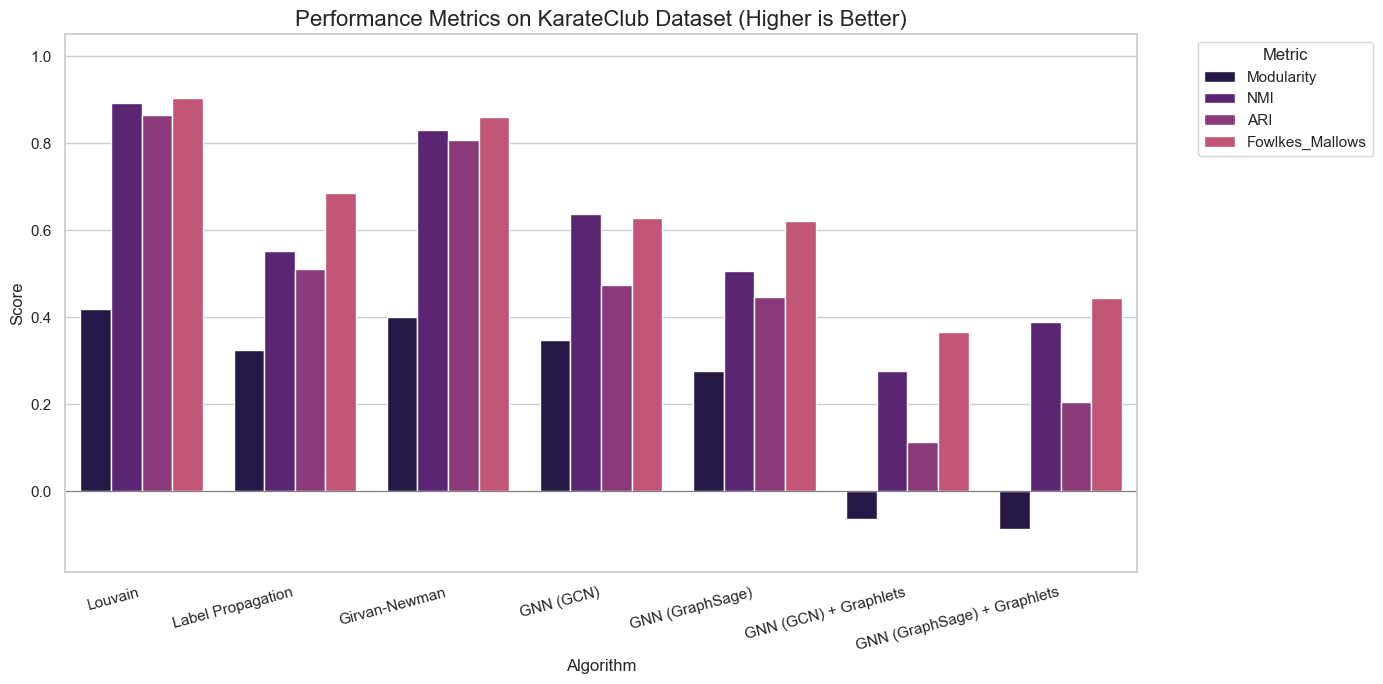

C:\Users\jmlim\AppData\Local\Temp\ipykernel_10808\3801098827.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='Algorithm', y=metric_to_plot_min, ax=ax1,


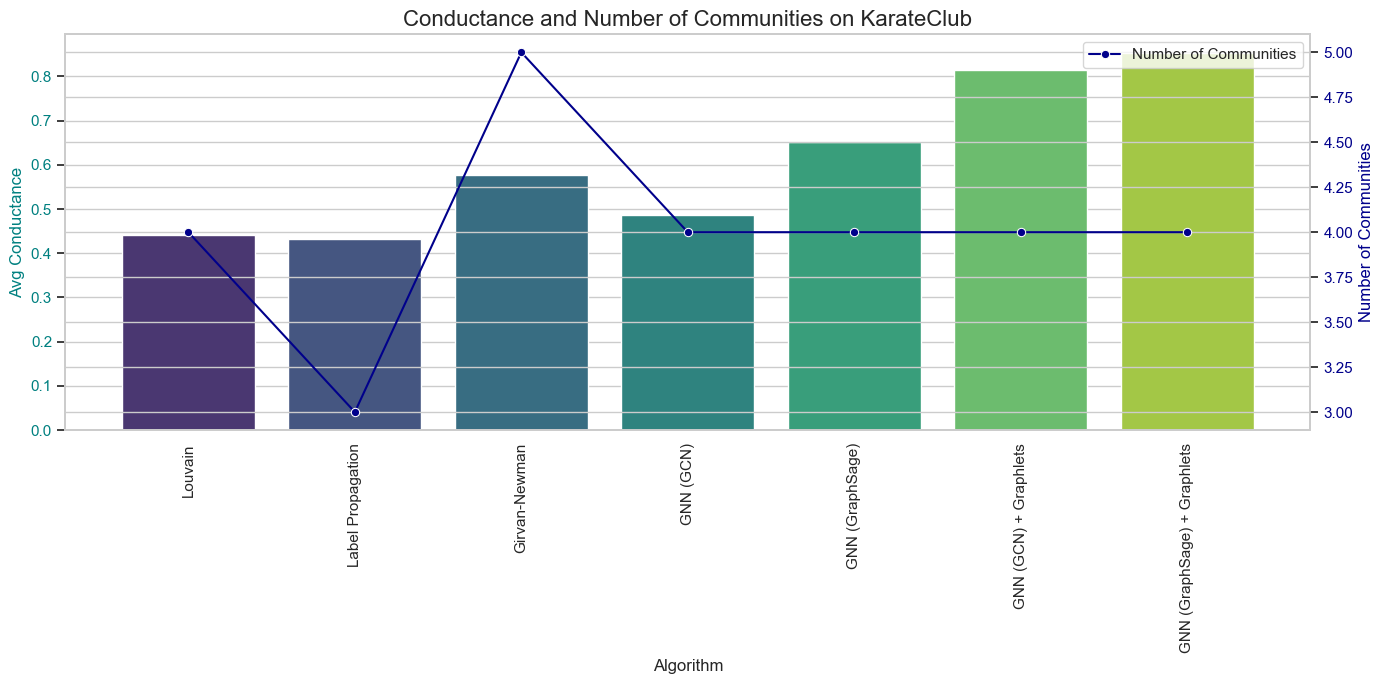

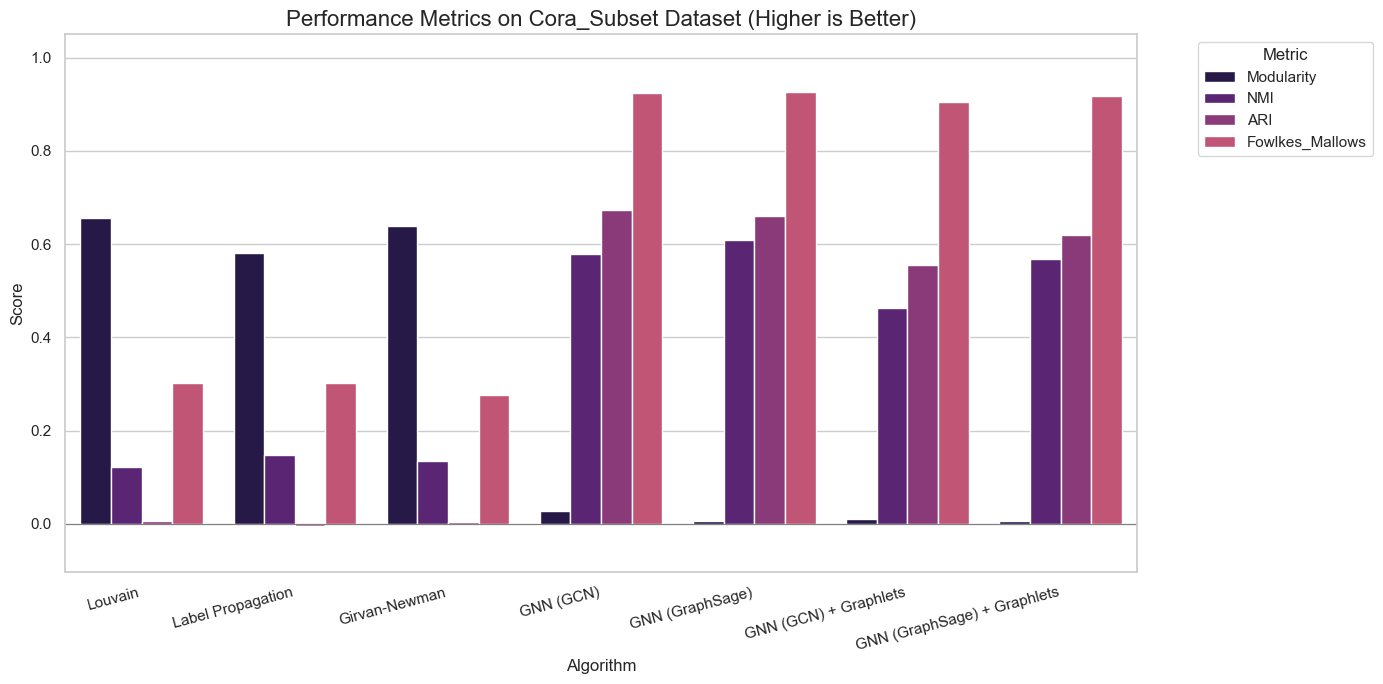

C:\Users\jmlim\AppData\Local\Temp\ipykernel_10808\3801098827.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='Algorithm', y=metric_to_plot_min, ax=ax1,


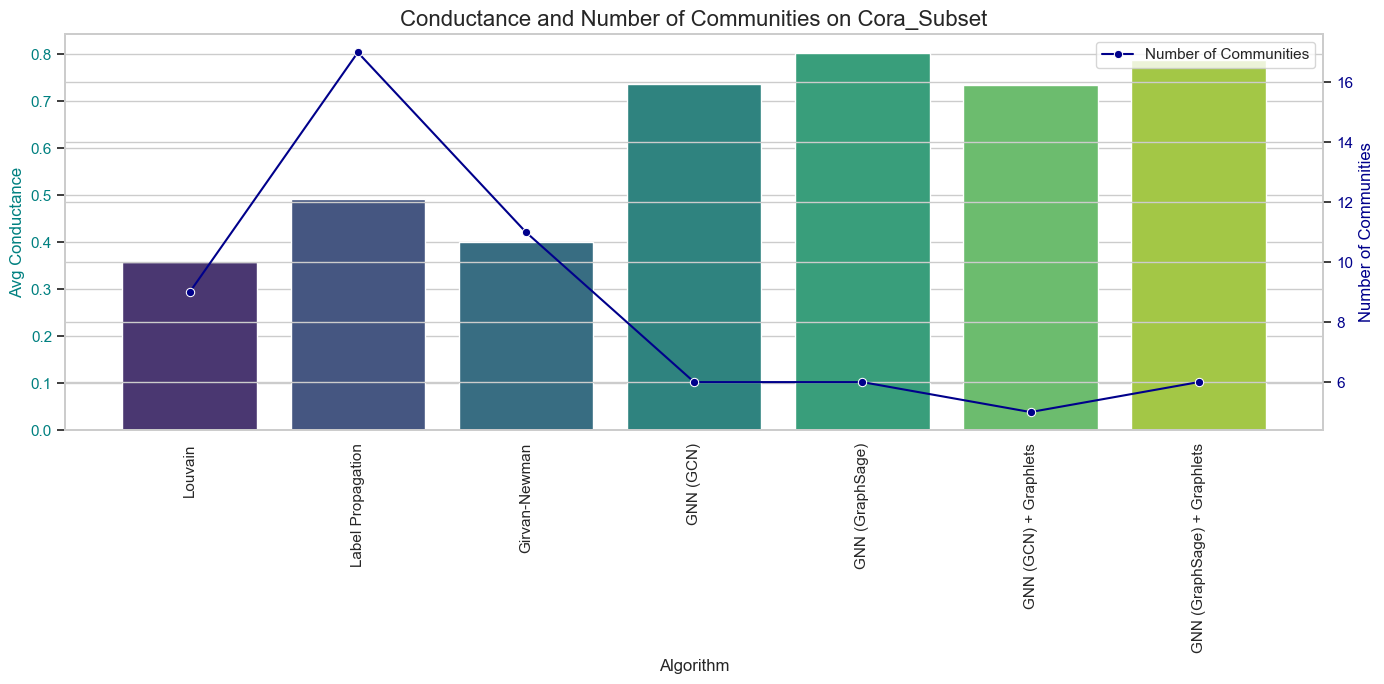

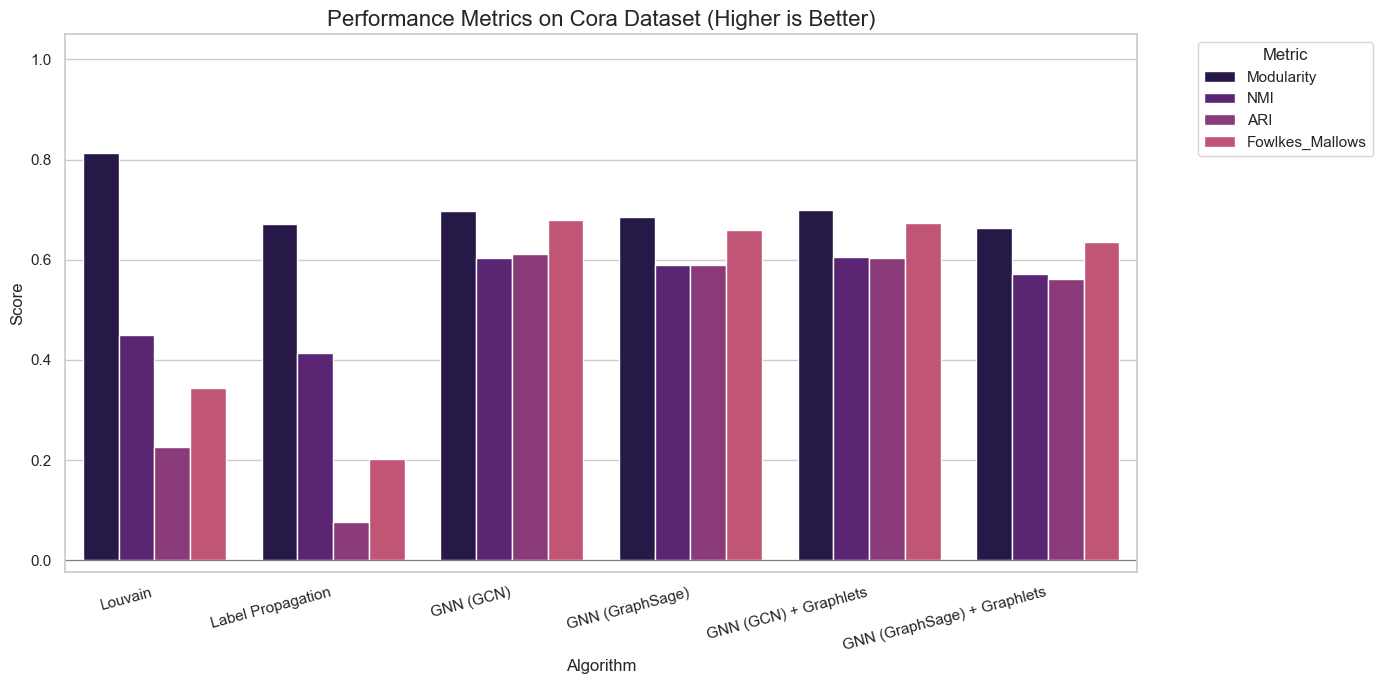

C:\Users\jmlim\AppData\Local\Temp\ipykernel_10808\3801098827.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='Algorithm', y=metric_to_plot_min, ax=ax1,


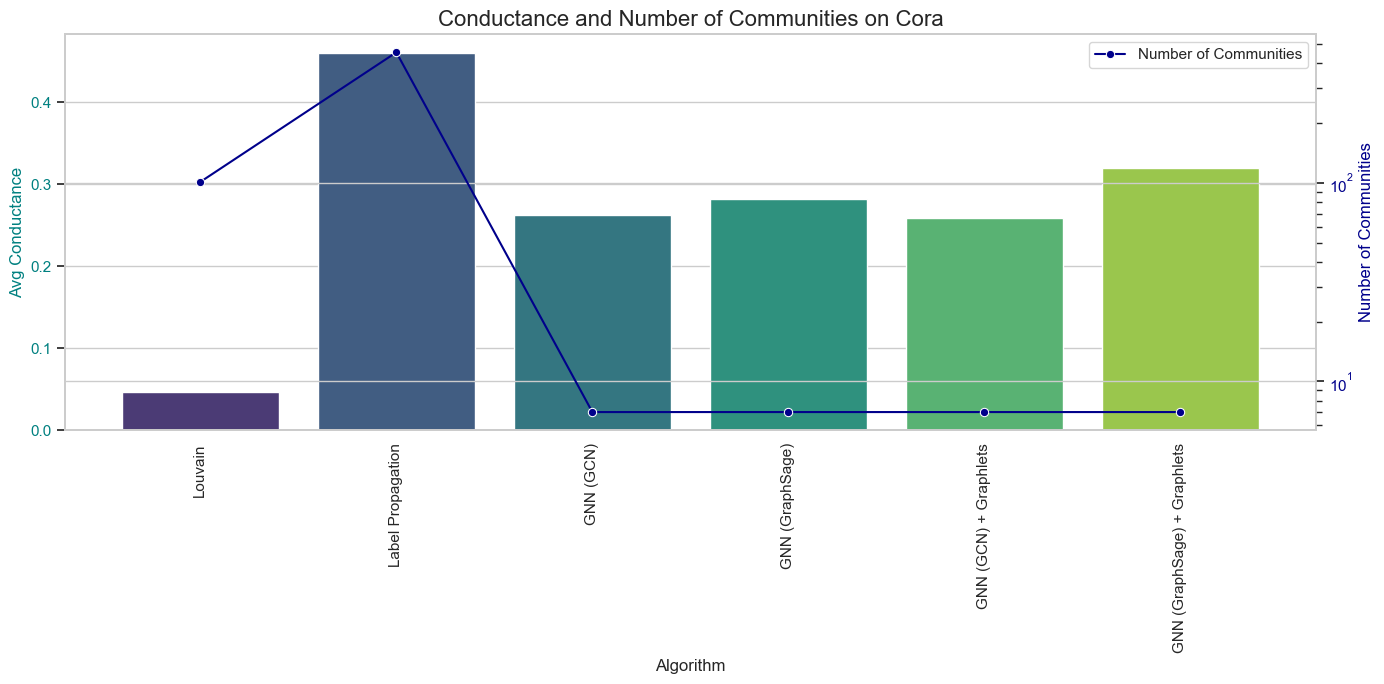

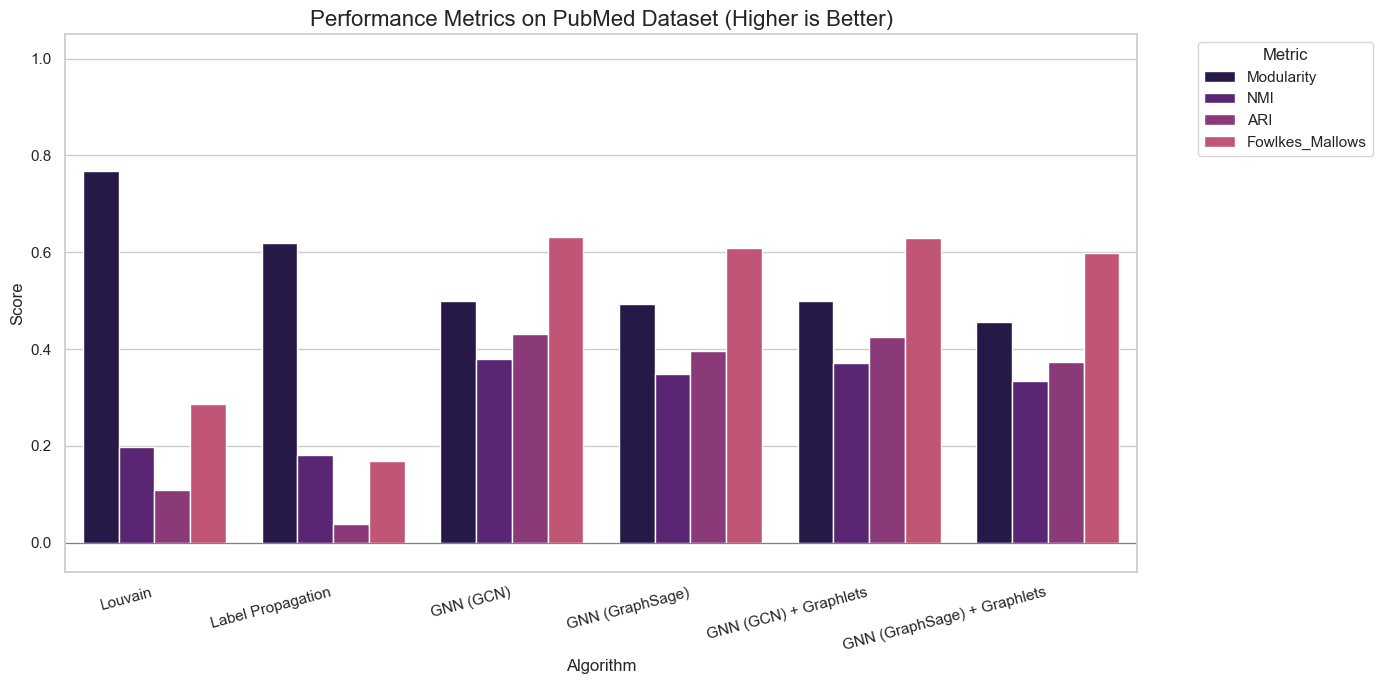

C:\Users\jmlim\AppData\Local\Temp\ipykernel_10808\3801098827.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='Algorithm', y=metric_to_plot_min, ax=ax1,


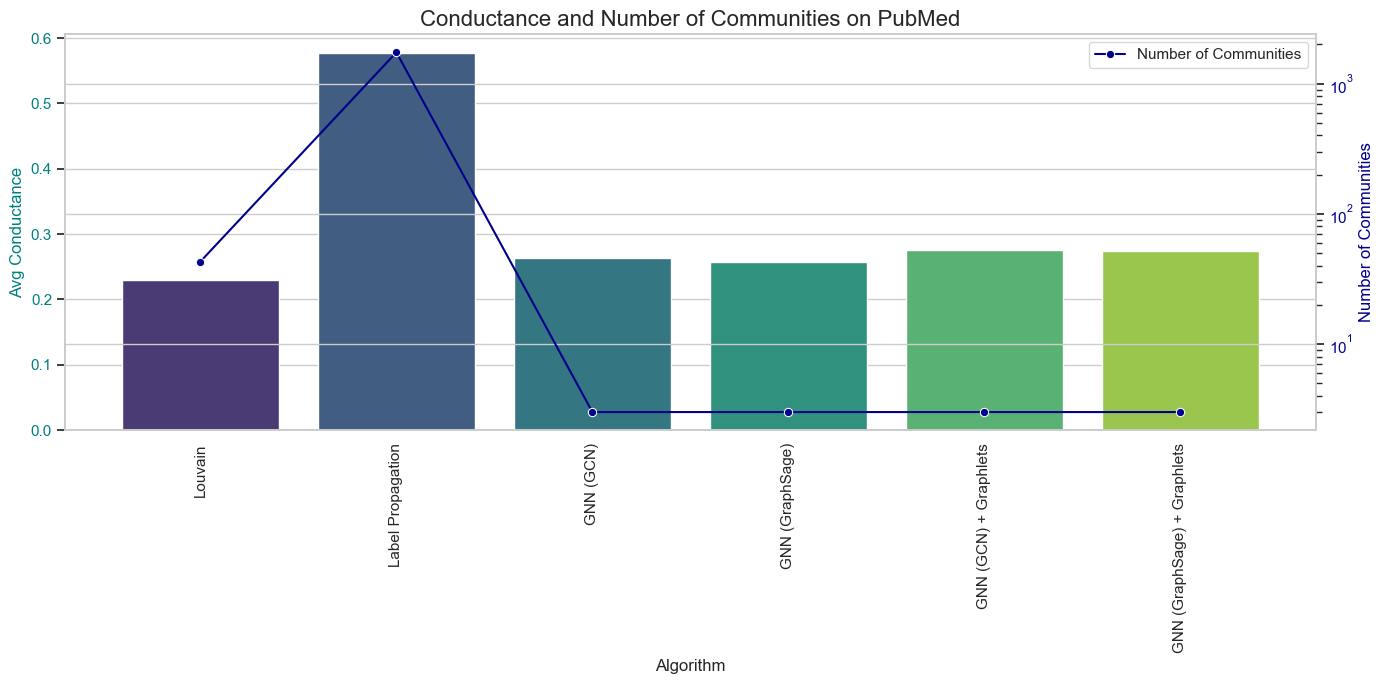

In [24]:
def plot_metrics(df, dataset_name):
    """Plots metrics for a given dataset."""
    data = df[df['Dataset'] == dataset_name].copy()

    cols_to_numeric = ['Num_Communities', 'Modularity', 'Avg_Conductance', 'NMI', 'ARI', 'Fowlkes_Mallows']
    for col in cols_to_numeric:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors='coerce')


    metrics_to_plot_max = ['Modularity', 'NMI', 'ARI', 'Fowlkes_Mallows']
    metric_to_plot_min = 'Avg_Conductance'

    melted_data_max = data.melt(id_vars='Algorithm', value_vars=metrics_to_plot_max, var_name='Metric', value_name='Score')
    melted_data_max['Score'] = pd.to_numeric(melted_data_max['Score'], errors='coerce')

    plt.figure(figsize=(14, 7))
    sns.barplot(data=melted_data_max, x='Algorithm', y='Score', hue='Metric')
    plt.title(f'Performance Metrics on {dataset_name} Dataset (Higher is Better)', fontsize=16)
    plt.ylabel('Score')
    plt.xlabel('Algorithm')
    plt.xticks(rotation=15, ha='right')
    score_min = melted_data_max['Score'].min()
    if np.isnan(score_min):
        plt.ylim(-0.2, 1.05)
    else:
        plt.ylim(max(score_min - 0.1, -0.2), 1.05)
    plt.axhline(0, color='grey', linewidth=0.8)
    plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    fig, ax1 = plt.subplots(figsize=(14, 7))

    sns.barplot(data=data, x='Algorithm', y=metric_to_plot_min, ax=ax1,
                palette="viridis", label='Avg Conductance (Lower is Better)')
    ax1.set_ylabel('Avg Conductance', color='teal')
    ax1.tick_params(axis='y', labelcolor='teal')
    ax1.set_xlabel('Algorithm')
    
    plt.xticks(rotation=90, ha='center')

    ax2 = ax1.twinx()
    sns.lineplot(data=data, x='Algorithm', y='Num_Communities', ax=ax2,
                 color='darkblue', marker='o', label='Number of Communities')
    ax2.set_ylabel('Number of Communities', color='darkblue')
    ax2.tick_params(axis='y', labelcolor='darkblue')
    if data['Num_Communities'].max() > 100:
        ax2.set_yscale('log')

    plt.title(f'Conductance and Number of Communities on {dataset_name}', fontsize=16)
    
    fig.tight_layout()  
    plt.show()
datasets = results_df['Dataset'].unique()

for dataset in datasets[1:]:
    plot_metrics(results_df, dataset)

## 4. Discussion of Results

The visualizations provide a clear picture of each algorithm's performance.

### Key Observations:

- **KarateClub**: On this small, simple graph, the traditional **Girvan-Newman** and **Louvain** algorithms perform exceptionally well on both internal (Modularity) and external (NMI, ARI) metrics. The GNNs, especially GraphSAGE, struggle, likely due to the small amount of data, which is insufficient for effective training. GraphSAGE's negative modularity score indicates that the communities it found are worse than a random partition.

- **Cora Subset**: Here, we see a more nuanced story. **Louvain** still dominates in Modularity, as it's designed to optimize it. However, the **GNN models (GCN and GraphSAGE) clearly outperform all traditional methods on the external metrics (NMI, ARI, FMS)**. This is a crucial finding: GNNs are better at finding communities that align with the ground truth, thanks to their ability to leverage node features during training.

- **Cora (Full)**: The trend continues on the full Cora dataset. **Louvain** achieves the highest modularity but produces a very large number of communities (101). The **GNN models** provide the best results on all external metrics, identifying a number of communities (7) that matches the ground-truth classes. Their conductance is higher than Louvain's but still reasonable, suggesting well-defined community boundaries.

- **PubMed**: The results on this large dataset are similar to Cora. **Louvain** and **Label Propagation** find a huge number of communities, which may not be practically useful. The **GNNs**, in contrast, find a number of communities that matches the ground truth (3) and achieve significantly better external validation scores. GraphSAGE and GCN perform almost identically on this dataset.

- **Impact of Graphlet-Enhanced Features**: The experiments show that augmenting or replacing node features with simple graphlet-based features (triangle counts) had a mixed impact. On the **KarateClub** dataset, which lacks rich initial features, using only graphlet features significantly worsened the performance of both GCN and GraphSAGE. This suggests that basic structural features alone are not sufficient for these models on small graphs. Conversely, on the feature-rich **Cora and PubMed** datasets, augmenting the existing features with graphlet features resulted in only marginal changes, with performance being very similar to the baseline GNNs. This indicates that when strong node features are already present, simple structural features may not provide significant additional value for these GNN architectures.

### Conclusion

This analysis demonstrates a clear trade-off between traditional and deep learning-based community detection methods:

1.  **Traditional Algorithms (e.g., Louvain)** are excellent for optimizing graph-native metrics like modularity and are fast and easy to use. However, they may not find communities that align with external, feature-based ground truths and can sometimes produce an impractically large number of clusters.
2.  **GNN-based Methods (GCN, GraphSAGE)** excel at finding semantically meaningful communities that align with ground-truth data, especially on datasets with rich node features. Their performance on smaller graphs or graphs without informative features can be suboptimal. They represent the state-of-the-art for semi-supervised community detection tasks.

## Link Prediction

In [23]:
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx
import networkx as nx
from torch_geometric.datasets import Planetoid, Twitch
from torch_geometric.utils import to_networkx

### Data Loading and Processing

In [24]:
csv_files = glob.glob('results/datasets/*.csv')
all_data = []
for f in csv_files:
    try:
        dataset_name = f.split('_')[0].split('/')[-1]
        
        df = pd.read_csv(f)
        df['dataset_name'] = dataset_name
        all_data.append(df)
    except pd.errors.EmptyDataError:
        print(f"Warning: The file {f} is empty and will be skipped.")

full_df = pd.concat(all_data, ignore_index=True)
metric_cols = ['AUC', 'MRR', 'Hits@10', 'Hits@50', 'Hits@100']
for col in metric_cols:
    full_df[col] = pd.to_numeric(full_df[col], errors='coerce')

full_df.dropna(subset=metric_cols, inplace=True)
avg_df = full_df.groupby(['dataset_name', 'model_name'])[metric_cols].mean().reset_index()

avg_df

,dataset_name,model_name,AUC,MRR,Hits@10,Hits@50,Hits@100
0,Citeseer,AdamicAdarModel,0.6445,0.1843,0.2933,0.2933,0.2933
1,Citeseer,CommonNeighborsModel,0.6444,0.1136,0.2933,0.2933,0.2933
2,Citeseer,DecisionTreeModel,0.7122,0.0787,0.3680,0.5073,0.5205
3,Citeseer,GCNModel1,0.7482,0.0642,0.1202,0.3314,0.5337
4,Citeseer,GCNModel2,0.9244,0.3905,0.5660,0.7375,0.8270
5,Citeseer,GraphSAGEModel1,0.5966,0.0740,0.1628,0.3050,0.3798
6,Citeseer,GraphSAGEModel2,0.8611,0.2445,0.4340,0.5484,0.6041
7,Citeseer,JaccardIndexModel,0.6446,0.1645,0.2933,0.2933,0.2933
8,Citeseer,KNNModel,0.7202,0.0773,0.4604,0.5029,0.5308
9,Citeseer,LogisticRegressionModel,0.6413,0.2212,0.4062,0.5059,0.5264


### Brief oveview of the networks' properties

In [23]:
datasets_to_analyze = sorted(avg_df['dataset_name'].unique()) if not avg_df.empty else []
print(f"Ready to analyze {len(datasets_to_analyze)} datasets: {datasets_to_analyze}")

Ready to analyze 4 datasets: ['Citeseer', 'Cora', 'Twitch-DE', 'Twitch-EN']


In [ ]:
network_stats = []
datasets_to_analyze = sorted(avg_df['dataset_name'].unique()) if not avg_df.empty else []

print(f"Analyzing {len(datasets_to_analyze)} datasets to gather network statistics...")

for dataset_name in datasets_to_analyze:
    print(f"  - Processing {dataset_name}...")
    
    path = '/tmp/'
    if dataset_name.lower().startswith('twitch'):
        country_code = dataset_name.split('-')[-1].upper()
        dataset = Twitch(root=path + "Twitch", name=country_code)
    elif dataset_name.lower() in ['cora', 'citeseer', 'pubmed']:
        dataset = Planetoid(root=path + dataset_name, name=dataset_name)
    else:
        print(f"    Warning: Skipping '{dataset_name}', direct loading not configured.")
        continue

    full_graph_data = dataset[0]
    
    G = to_networkx(full_graph_data, to_undirected=True)
    
    num_nodes = full_graph_data.num_nodes
    num_edges = full_graph_data.num_edges
    
    stats_dict = {
        'Dataset': dataset_name,
        'Nodes': num_nodes,
        'Edges': num_edges,
        'Avg. Node Degree': (2 * num_edges) / num_nodes,
        'Node Feature Dim.': full_graph_data.num_features,
        'Density': nx.density(G),
        'Is Connected': nx.is_connected(G),
        '# Components': nx.number_connected_components(G)
    }
    network_stats.append(stats_dict)

stats_df = pd.DataFrame(network_stats).set_index('Dataset')
display(stats_df.style.format({
    'Avg. Node Degree': '{:.2f}',
    'Density': '{:.6f}'
}))


Analyzing 4 datasets to gather network statistics...
  - Processing Citeseer...
  - Processing Cora...
  - Processing Twitch-DE...
  - Processing Twitch-EN...


,Nodes,Edges,Avg. Node Degree,Node Feature Dim.,Density,Is Connected,# Components
Dataset,,,,,,,
Citeseer,3327,9104,5.47,3703,0.000823,False,438
Cora,2708,10556,7.80,1433,0.001440,False,78
Twitch-DE,9498,315774,66.49,128,0.003606,True,1
Twitch-EN,7126,77774,21.83,128,0.001672,True,1


### Performance analysis

Performance metrics:
- **AUC:** Area Under the ROC Curve, a measure of the model's ability to distinguish between positive and negative classes.
- **MRR:** Mean Reciprocal Rank, a measure of the model's ranking quality. It is the average of the reciprocal ranks of the first relevant item.
- **Hits@K:** The proportion of times the true positive is found within the top K predictions.

#### Overal comparison of metrics across datasets

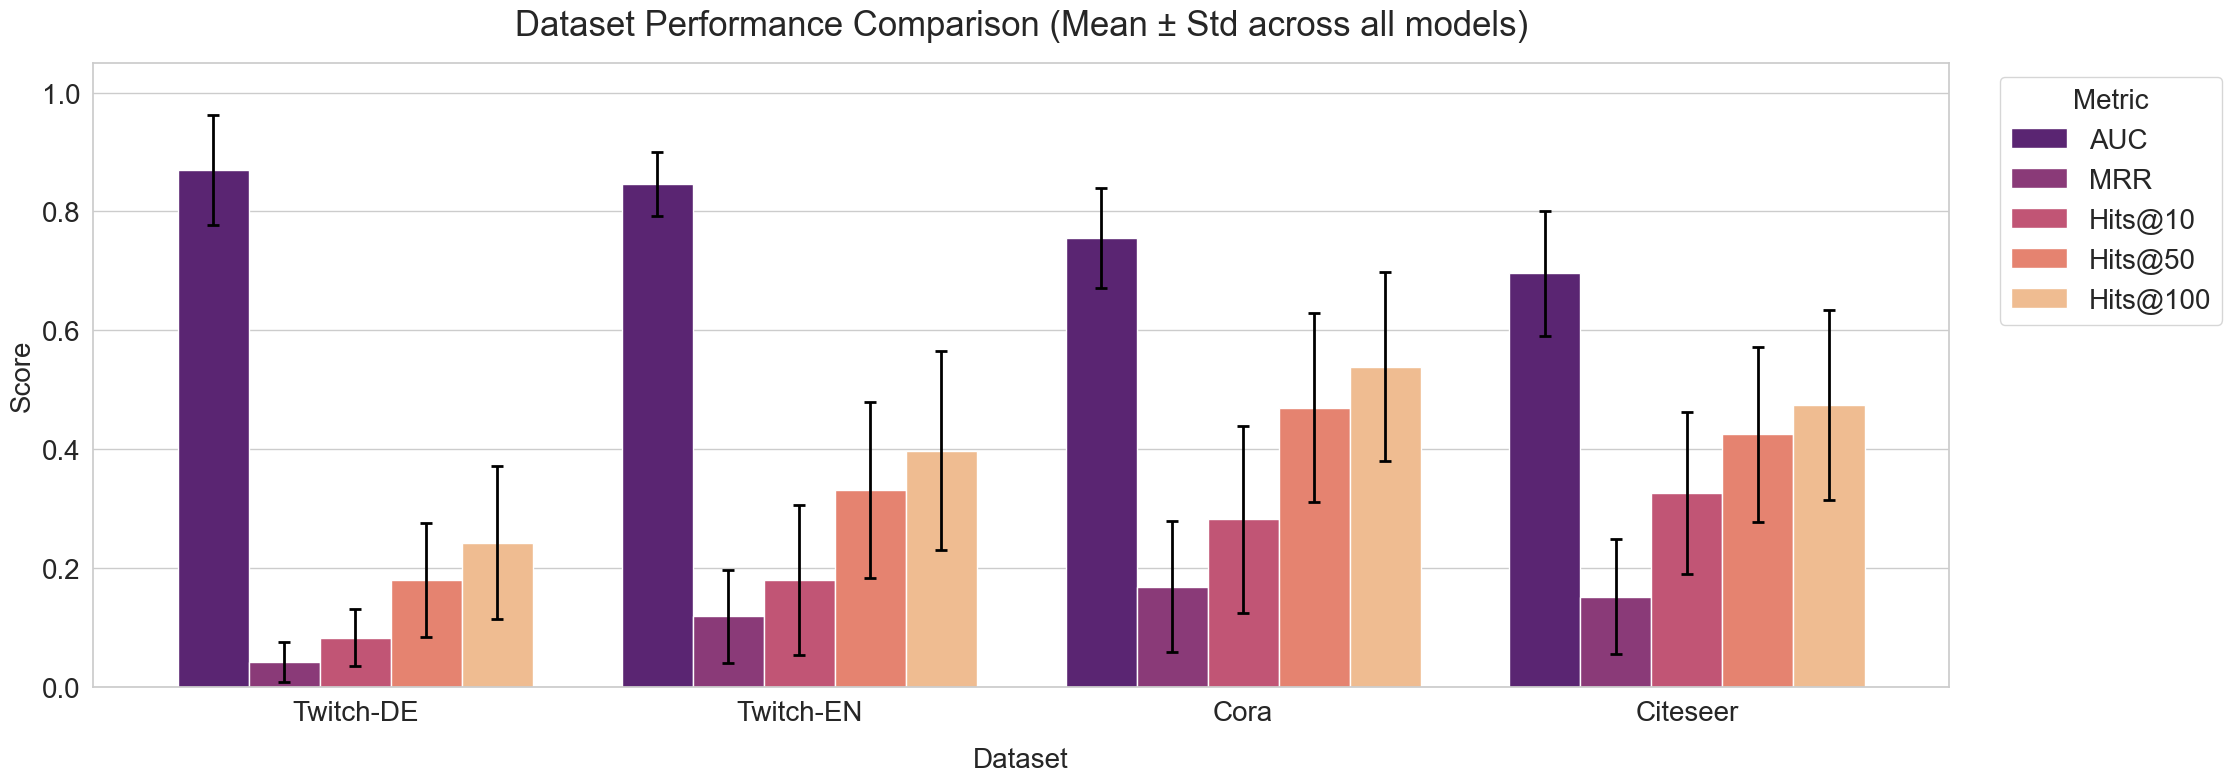


SUMMARY STATISTICS: Dataset performance across all models


,dataset_name,AUC_mean,AUC_var,MRR_mean,MRR_var,Hits@10_mean,Hits@10_var,Hits@100_mean,Hits@100_var
2,Twitch-DE,0.8689,0.0086,0.0419,0.0011,0.0832,0.0024,0.2425,0.0166
3,Twitch-EN,0.8465,0.0029,0.1189,0.0060,0.1795,0.0159,0.3974,0.0280
1,Cora,0.7547,0.0070,0.1690,0.0120,0.2817,0.0245,0.5385,0.0252
0,Citeseer,0.6961,0.0111,0.1520,0.0093,0.3266,0.0186,0.4742,0.0253


In [25]:
def plot_dataset_metrics(filename='dataset_comparison'):
    save_fig = True
    dataset_stats = []
    
    for dataset in avg_df['dataset_name'].unique():
        dataset_data = avg_df[avg_df['dataset_name'] == dataset]
        
        stats_dict = {
            'dataset_name': dataset,
            'AUC_mean': dataset_data['AUC'].mean(),
            'AUC_var': dataset_data['AUC'].var(),
            'MRR_mean': dataset_data['MRR'].mean(),
            'MRR_var': dataset_data['MRR'].var(),
            'Hits@10_mean': dataset_data['Hits@10'].mean(),
            'Hits@10_var': dataset_data['Hits@10'].var(),
            'Hits@50_mean': dataset_data['Hits@50'].mean(),
            'Hits@50_var': dataset_data['Hits@50'].var(),
            'Hits@100_mean': dataset_data['Hits@100'].mean(),
            'Hits@100_var': dataset_data['Hits@100'].var()
        }
        dataset_stats.append(stats_dict)
    
    dataset_stats_df = pd.DataFrame(dataset_stats)
    dataset_stats_df = dataset_stats_df.sort_values(by='AUC_mean', ascending=False)
    
    mean_cols = ['AUC_mean', 'MRR_mean', 'Hits@10_mean', 'Hits@50_mean', 'Hits@100_mean']
    var_cols = ['AUC_var', 'MRR_var', 'Hits@10_var', 'Hits@50_var', 'Hits@100_var']
    
    melted_means = dataset_stats_df.melt(
        id_vars=['dataset_name'],
        value_vars=mean_cols,
        var_name='Metric',
        value_name='Mean'
    )
    
    melted_vars = dataset_stats_df.melt(
        id_vars=['dataset_name'],
        value_vars=var_cols,
        var_name='Metric',
        value_name='Variance'
    )
    
    melted_means['Metric'] = melted_means['Metric'].str.replace('_mean', '')
    melted_vars['Metric'] = melted_vars['Metric'].str.replace('_var', '')
    
    plot_data = pd.merge(melted_means, melted_vars, on=['dataset_name', 'Metric'])
    
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(25, 8))
    
    magma_colors = sns.color_palette('magma', n_colors=6)
    custom_palette = magma_colors[1:6]
    
    barplot = sns.barplot(
        data=plot_data,
        x='dataset_name',
        y='Mean',
        hue='Metric',
        ax=ax,
        palette=custom_palette
    )
    
    datasets = plot_data['dataset_name'].unique()
    metrics = plot_data['Metric'].unique()
    bar_positions = {}
    for i, dataset in enumerate(datasets):
        for j, metric in enumerate(metrics):
            bar_width = 0.8 / len(metrics)
            x_pos = i + (j - len(metrics)/2 + 0.5) * bar_width
            bar_positions[(dataset, metric)] = x_pos
    for _, row in plot_data.iterrows():
        dataset = row['dataset_name']
        metric = row['Metric']
        mean_val = row['Mean']
        var_val = row['Variance']
        std_val = var_val ** 0.5
        
        x_pos = bar_positions[(dataset, metric)]
        ax.errorbar(x_pos, mean_val, yerr=std_val, 
                   fmt='none', color='black', capsize=4, capthick=2, linewidth=2)
    
    ax.set_title('Dataset Performance Comparison (Mean ± Std across all models)', fontsize=25, pad=20)
    ax.set_xlabel('Dataset', fontsize=20, labelpad=15)
    ax.set_ylabel('Score', fontsize=20)
    ax.tick_params(axis='x', rotation=0, labelsize=20)
    ax.tick_params(axis='y', labelsize=20)
    ax.set_ylim(0, 1.05)
    
    for p in barplot.patches:
        if p.get_height() > 0.01:
            barplot.annotate("",
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='center',
                           xytext=(0, 9),
                           textcoords='offset points',
                           fontsize=0)
    
    plt.legend(title='Metric', fontsize=20, title_fontsize=20, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    
    if save_fig:
        fig.savefig(f'results/plots/{filename}.png', bbox_inches='tight')
    plt.show()
    
    print("\n" + "="*80)
    print("SUMMARY STATISTICS: Dataset performance across all models")
    print("="*80)
    
    summary_table = dataset_stats_df.copy()
    summary_table = summary_table.round(4)
    
    col_order = ['dataset_name']
    for metric in ['AUC', 'MRR', 'Hits@10', 'Hits@100']:
        col_order.extend([f'{metric}_mean', f'{metric}_var'])
    
    summary_table = summary_table[col_order]
    
    display(summary_table.style.format({
        col: '{:.4f}' for col in summary_table.columns if col != 'dataset_name'
    }))
    
    return dataset_stats_df

dataset_performance_stats = plot_dataset_metrics()

Cora and Citeseer get better results on ranking metrics (MRR, Hits@K) while Twitch networks are more suitable for the crude binary classification (AUC).

#### Performance of models on each network

In [26]:
def plot_models_metrics_on_network(dataset_name):
    save_fig = True
    dataset_results_df = avg_df[avg_df['dataset_name'] == dataset_name].sort_values(by='AUC', ascending=False)
 
    melted_df = dataset_results_df.melt(
        id_vars=['dataset_name', 'model_name'],
        value_vars=metric_cols,
        var_name='Metric',
        value_name='Score'
    )

    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(25, 8))

    barplot = sns.barplot(
        data=melted_df,
        x='model_name',
        y='Score',
        hue='Metric',
        ax=ax,
        palette='magma'
    )

    if len(dataset_results_df['model_name'].unique()) <= 5:
        rot=0
    else:
        rot=45
    ax.set_title(f'Model Performance on {dataset_name} Dataset', fontsize=22, pad=20)
    ax.set_xlabel('Model', fontsize=16, labelpad=15)
    ax.set_ylabel('Score', fontsize=16)
    ax.tick_params(axis='x', rotation=rot, labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_ylim(0, 1.05)
    
    for p in barplot.patches:
        if p.get_height() > 0.01:
            barplot.annotate(format(p.get_height(), '.2f'),
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha = 'center', va = 'center',
                           xytext = (0, 9),
                           textcoords = 'offset points',
                           fontsize=9)

    plt.legend(title='Metric', fontsize=12, title_fontsize=14, bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    if save_fig:
        fig.savefig(f'results/plots/{dataset_name}_model_performance.png', bbox_inches='tight')
    plt.show()

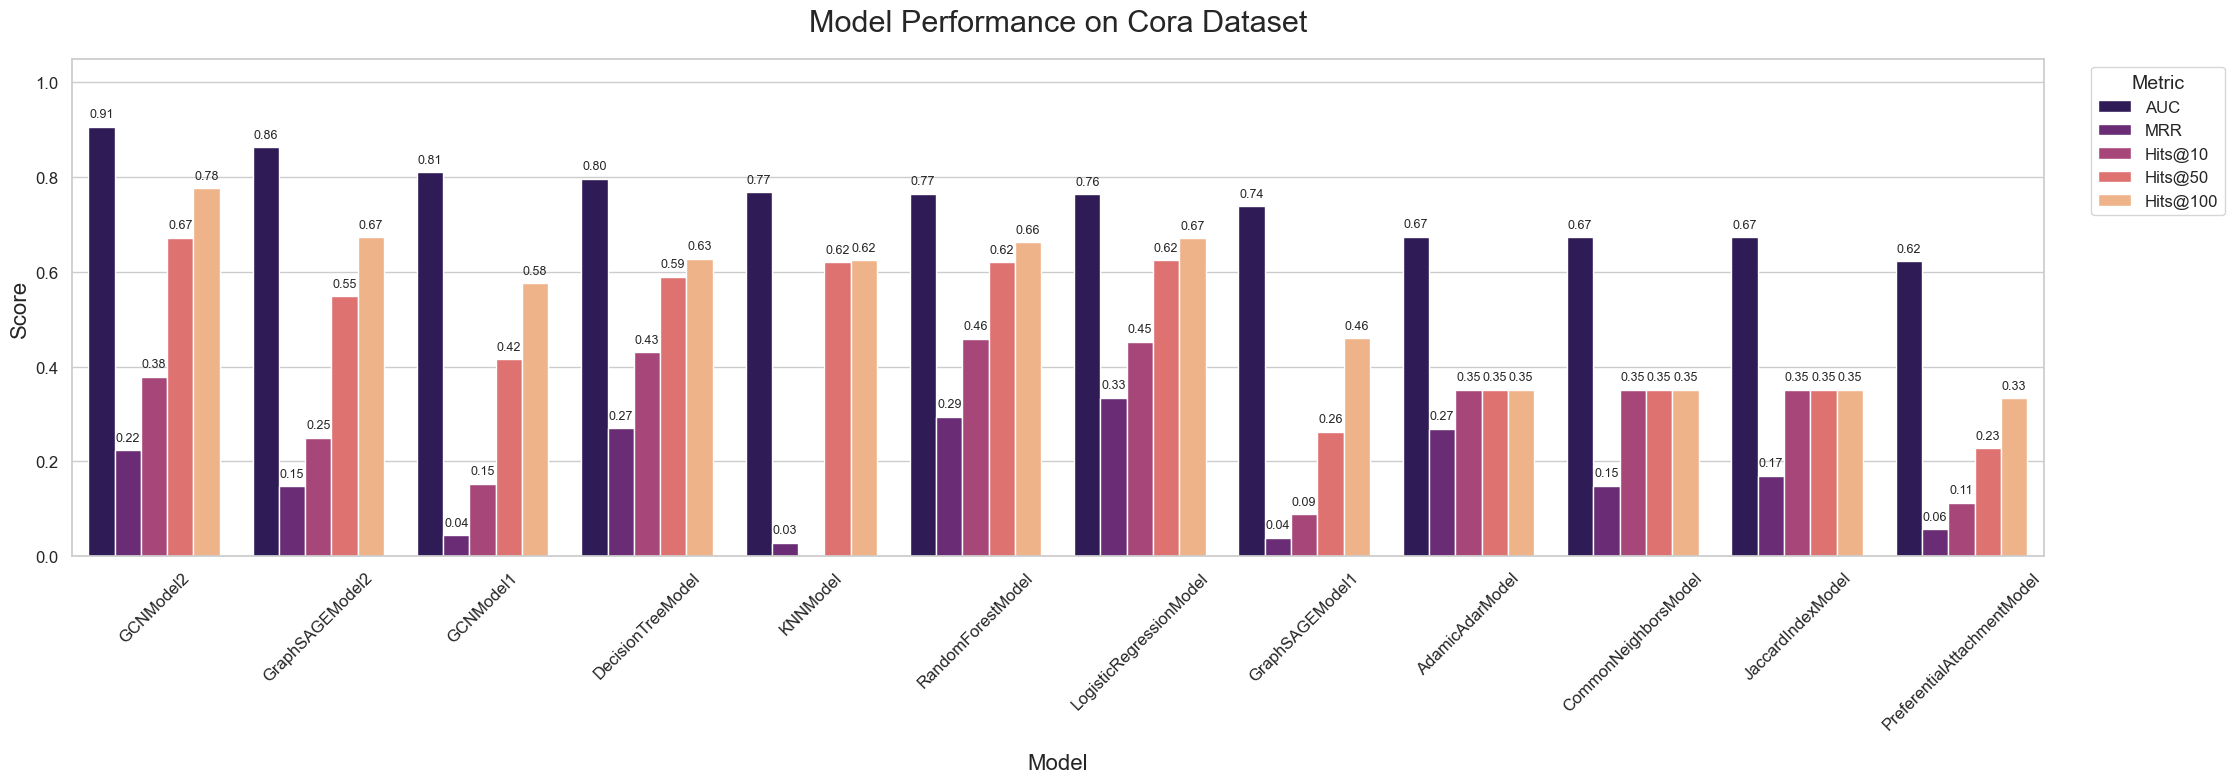

In [27]:
plot_models_metrics_on_network('Cora')

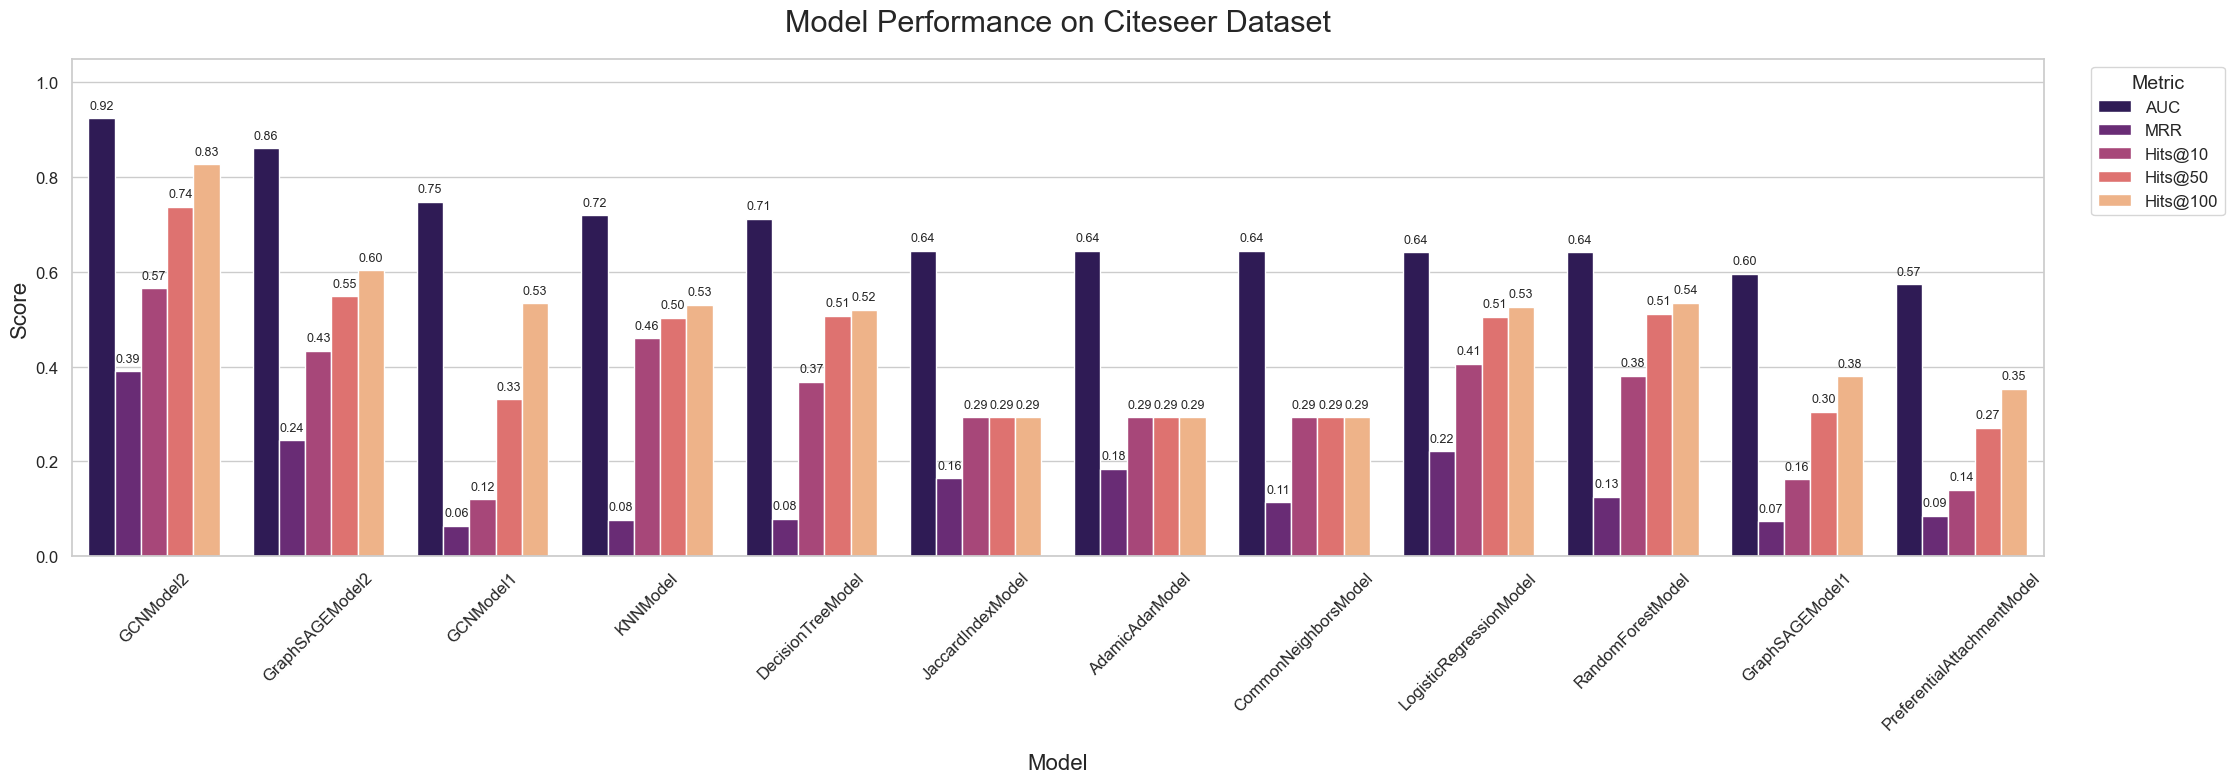

In [28]:
plot_models_metrics_on_network('Citeseer')

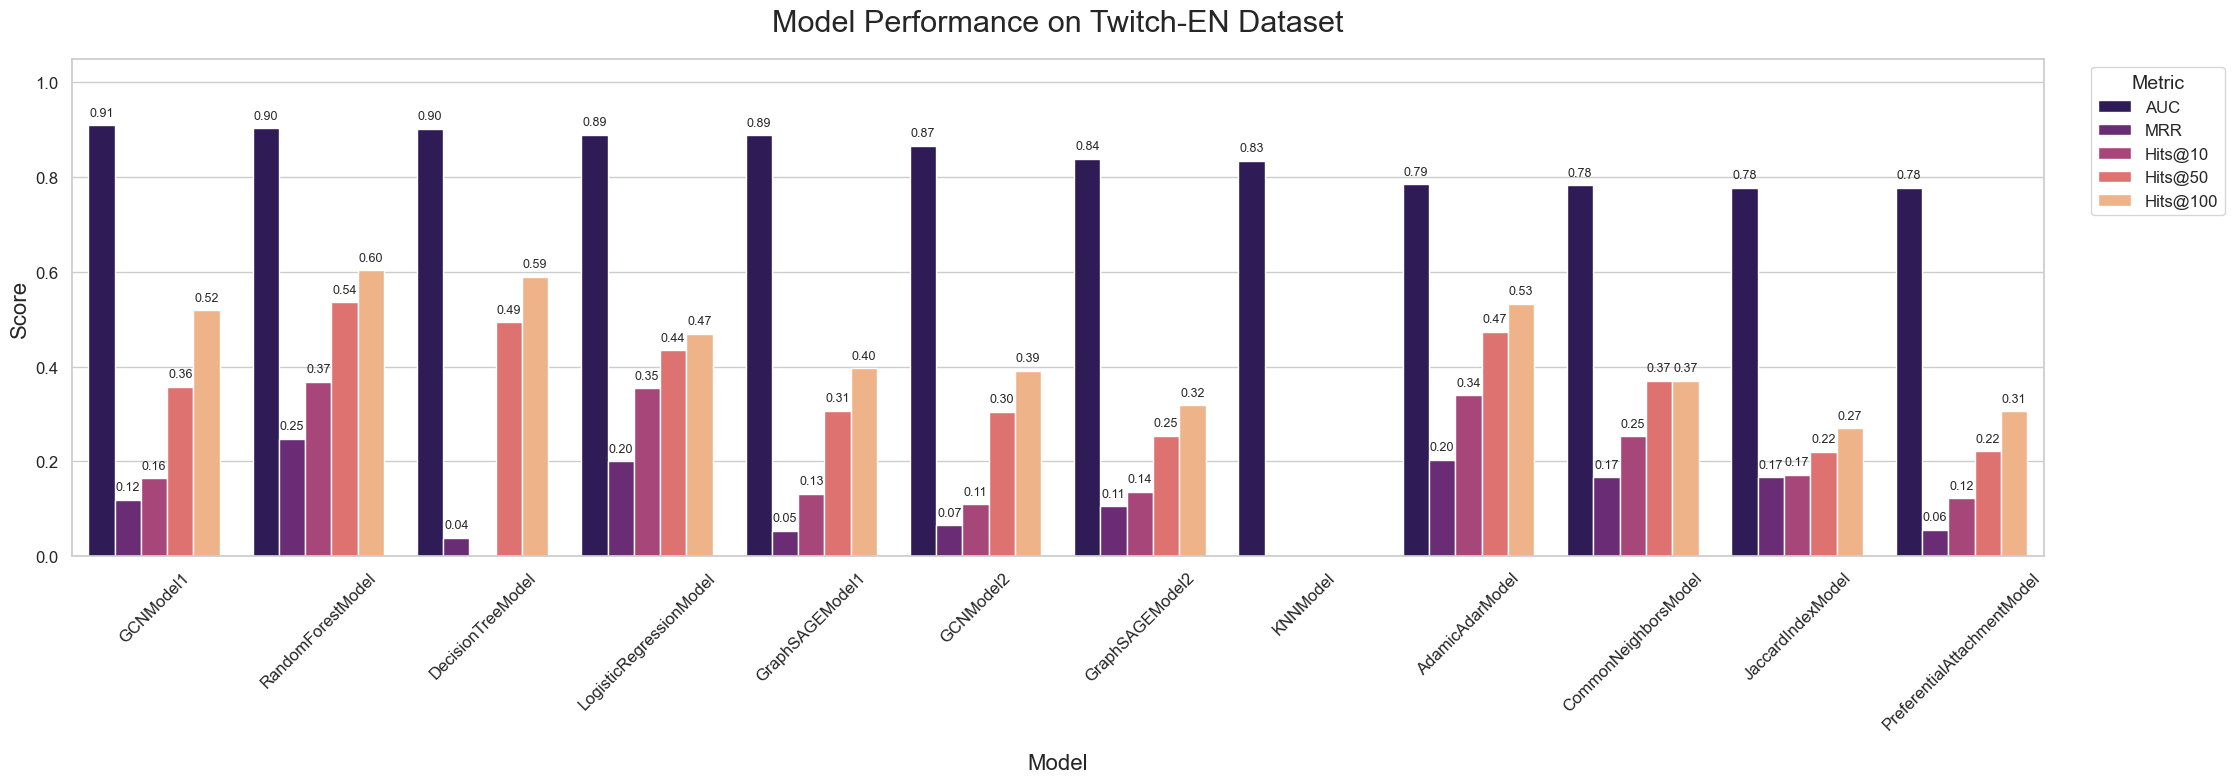

In [29]:
plot_models_metrics_on_network("Twitch-EN")

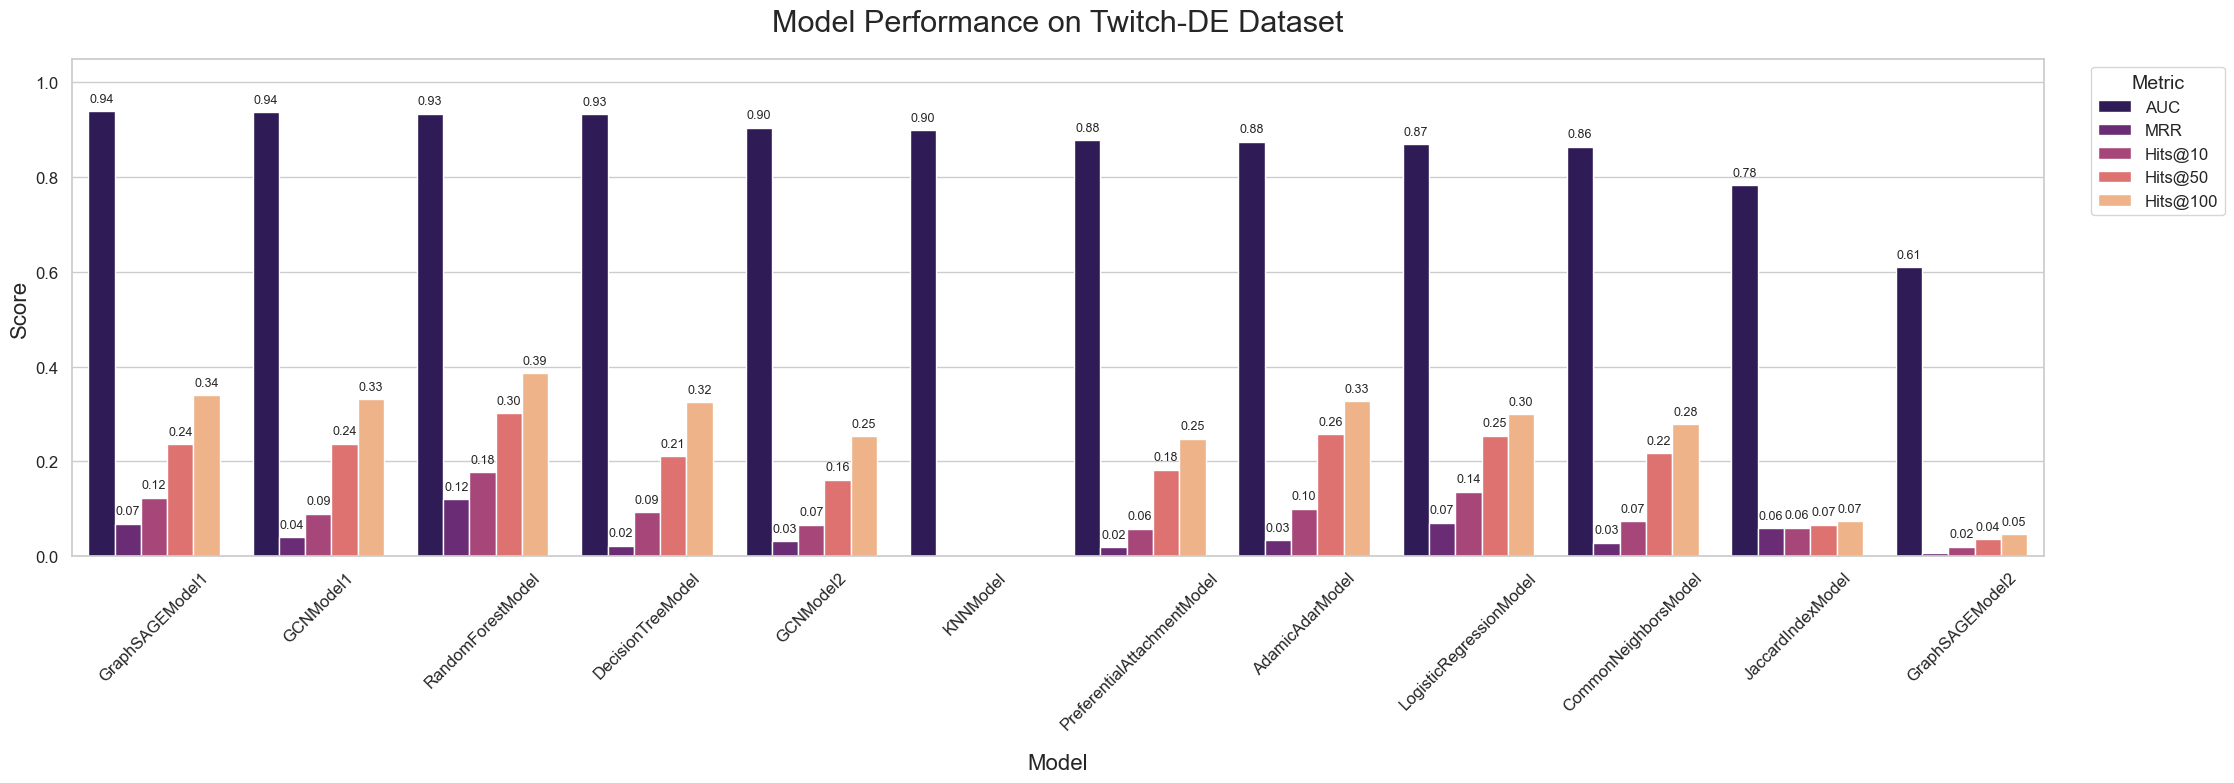

In [30]:
plot_models_metrics_on_network('Twitch-DE')

#### Overall comparison of models across all networks

In [31]:
def plot_overall_model_metrics(filename, model_filter=None, show_variance=True, show_values=False):
    save_fig = True
    
    model_stats = []
    
    for model in avg_df['model_name'].unique():
        model_data = avg_df[avg_df['model_name'] == model]
        
        stats_dict = {
            'model_name': model,
            'AUC_mean': model_data['AUC'].mean(),
            'AUC_var': model_data['AUC'].var(),
            'MRR_mean': model_data['MRR'].mean(),
            'MRR_var': model_data['MRR'].var(),
            'Hits@10_mean': model_data['Hits@10'].mean(),
            'Hits@10_var': model_data['Hits@10'].var(),
            'Hits@50_mean': model_data['Hits@50'].mean(),
            'Hits@50_var': model_data['Hits@50'].var(),
            'Hits@100_mean': model_data['Hits@100'].mean(),
            'Hits@100_var': model_data['Hits@100'].var()
        }
        model_stats.append(stats_dict)
    
    model_stats_df = pd.DataFrame(model_stats)
    model_stats_df = model_stats_df.sort_values(by='AUC_mean', ascending=False)
    mean_cols = ['AUC_mean', 'MRR_mean', 'Hits@10_mean', 'Hits@50_mean', 'Hits@100_mean']
    var_cols = ['AUC_var', 'MRR_var', 'Hits@10_var', 'Hits@50_var', 'Hits@100_var']
    
    melted_means = model_stats_df.melt(
        id_vars=['model_name'],
        value_vars=mean_cols,
        var_name='Metric',
        value_name='Mean'
    )
    melted_vars = model_stats_df.melt(
        id_vars=['model_name'],
        value_vars=var_cols,
        var_name='Metric',
        value_name='Variance'
    )
    
    melted_means['Metric'] = melted_means['Metric'].str.replace('_mean', '')
    melted_vars['Metric'] = melted_vars['Metric'].str.replace('_var', '')
    
    plot_data = pd.merge(melted_means, melted_vars, on=['model_name', 'Metric'])

    if model_filter is not None:
        plot_data = plot_data[plot_data['model_name'].isin([k for k, v in model_filter.items() if v])]
    
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(25, 8))
    
    magma_colors = sns.color_palette('magma', n_colors=7)
    custom_palette = magma_colors[2:7] if show_variance else magma_colors[0:5]
    
    
    barplot = sns.barplot(
        data=plot_data,
        x='model_name',
        y='Mean',
        hue='Metric',
        ax=ax,
        palette=custom_palette
    )
    
    if show_variance:
        models = plot_data['model_name'].unique()
        metrics = plot_data['Metric'].unique()
        
        bar_positions = {}
        for i, model in enumerate(models):
            for j, metric in enumerate(metrics):
                bar_width = 0.8 / len(metrics)
                x_pos = i + (j - len(metrics)/2 + 0.5) * bar_width
                bar_positions[(model, metric)] = x_pos
        
        for _, row in plot_data.iterrows():
            model = row['model_name']
            metric = row['Metric']
            mean_val = row['Mean']
            var_val = row['Variance']
            std_val = var_val ** 0.5
            
            x_pos = bar_positions[(model, metric)]
            ax.errorbar(x_pos, mean_val, yerr=std_val, 
                       fmt='none', color='black', capsize=4, capthick=2, linewidth=2)
    
    rot = 0 if model_filter is not None and sum(model_filter.values()) <= 5 else 45

    title = 'Model performance across all datasets'
    if show_variance:
        title += ' (Mean ± Std)'
    else:
        title += ' (Mean)'
    
    ax.set_title(title, fontsize=25, pad=20)
    ax.set_xlabel('Model', fontsize=25, labelpad=15)
    ax.set_ylabel('Score', fontsize=25)
    ax.tick_params(axis='x', rotation=rot, labelsize=20)
    ax.tick_params(axis='y', labelsize=20)
    ax.set_ylim(0, 1.05)
    
    if show_values:
        for p in barplot.patches:
            if p.get_height() > 0.01:
                barplot.annotate(format(p.get_height(), '.3f'),
                               (p.get_x() + p.get_width() / 2., p.get_height()),
                               ha='center', va='center',
                               xytext=(0, 9),
                               textcoords='offset points',
                               fontsize=15)
    
    plt.legend(title='Metric', fontsize=20, title_fontsize=20, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    
    if save_fig:
        fig.savefig(f'results/plots/{filename}', bbox_inches='tight')
    plt.show()
    
    print("\n" + "="*80)
    print("SUMMARY STATISTICS: Model performance across all datasets")
    print("="*80)
    
    summary_table = model_stats_df.copy()
    summary_table = summary_table.round(4)
    
    col_order = ['model_name']
    for metric in ['AUC', 'MRR', 'Hits@10', 'Hits@50', 'Hits@100']:
        col_order.extend([f'{metric}_mean', f'{metric}_var'])
    
    summary_table = summary_table[col_order]
    if model_filter is not None:
        summary_table = summary_table[summary_table['model_name'].isin([k for k, v in model_filter.items() if v])]
    
    display(summary_table.style.format({
        col: '{:.4f}' for col in summary_table.columns if col != 'model_name'
    }))
    
    return model_stats_df

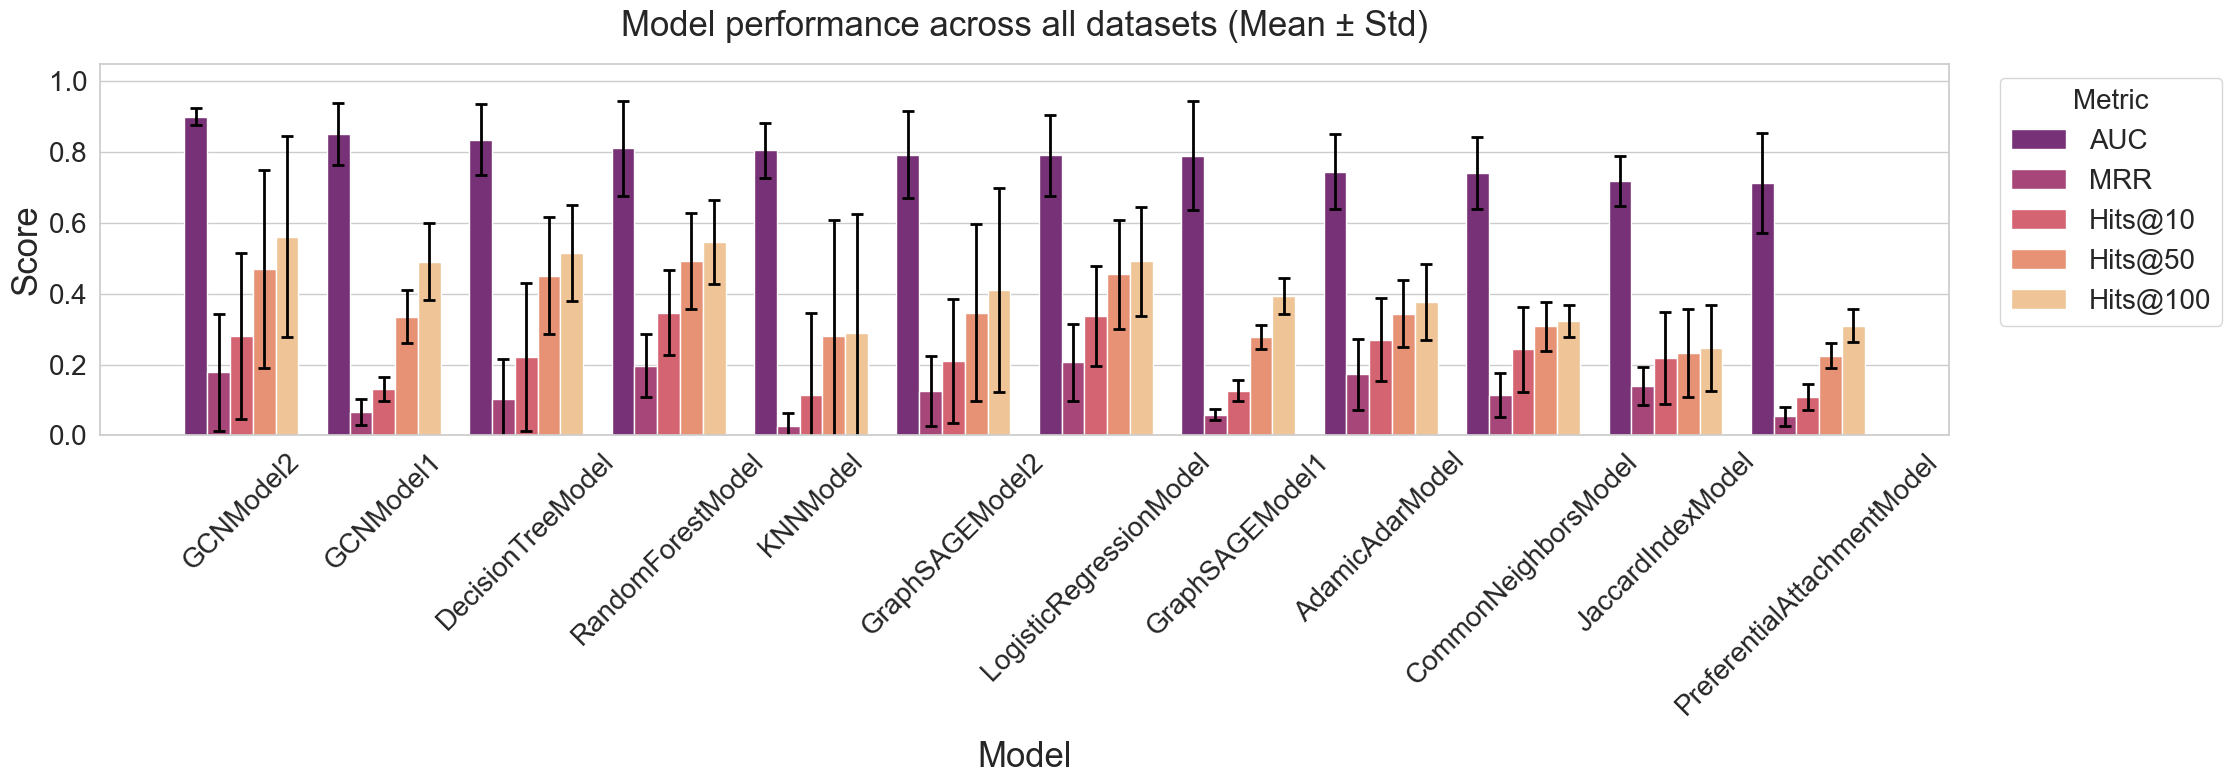


SUMMARY STATISTICS: Model performance across all datasets


,model_name,AUC_mean,AUC_var,MRR_mean,MRR_var,Hits@10_mean,Hits@10_var,Hits@50_mean,Hits@50_var,Hits@100_mean,Hits@100_var
4,GCNModel2,0.9003,0.0006,0.1779,0.0271,0.2804,0.0554,0.4691,0.0784,0.5619,0.0802
3,GCNModel1,0.8514,0.0077,0.0668,0.0014,0.1320,0.0011,0.3357,0.0055,0.4900,0.0118
2,DecisionTreeModel,0.8359,0.0102,0.1026,0.0130,0.2229,0.0437,0.4506,0.0273,0.5159,0.0182
11,RandomForestModel,0.8111,0.0182,0.1972,0.0077,0.3465,0.0143,0.4925,0.0184,0.5469,0.0142
8,KNNModel,0.8055,0.0061,0.0275,0.0013,0.1151,0.0530,0.2809,0.1075,0.2888,0.1127
6,GraphSAGEModel2,0.7936,0.0150,0.1264,0.0097,0.2102,0.0311,0.3468,0.0622,0.4107,0.0826
9,LogisticRegressionModel,0.7912,0.0130,0.2064,0.0117,0.3374,0.0196,0.4550,0.0240,0.4918,0.0236
5,GraphSAGEModel1,0.7908,0.0240,0.0588,0.0002,0.1267,0.0009,0.2777,0.0012,0.3941,0.0025
0,AdamicAdarModel,0.7446,0.0112,0.1726,0.0099,0.2710,0.0137,0.3439,0.0090,0.3764,0.0115
1,CommonNeighborsModel,0.7413,0.0103,0.1144,0.0038,0.2430,0.0143,0.3079,0.0047,0.3234,0.0019


In [32]:
# All models
model_filter = {
    "CommonNeighborsModel": True,
    "JaccardIndexModel": True,
    "AdamicAdarModel": True,
    "PreferentialAttachmentModel": True,
    "KNNModel": True,
    "LogisticRegressionModel": True,
    "DecisionTreeModel": True,
    "RandomForestModel": True,
    "GCNModel1": True,
    "GCNModel2": True,
    "GraphSAGEModel1": True,
    "GraphSAGEModel2": True,
    "SEALModel": True,
}
model_performance_stats = plot_overall_model_metrics(filename='all_models.png', model_filter=model_filter)

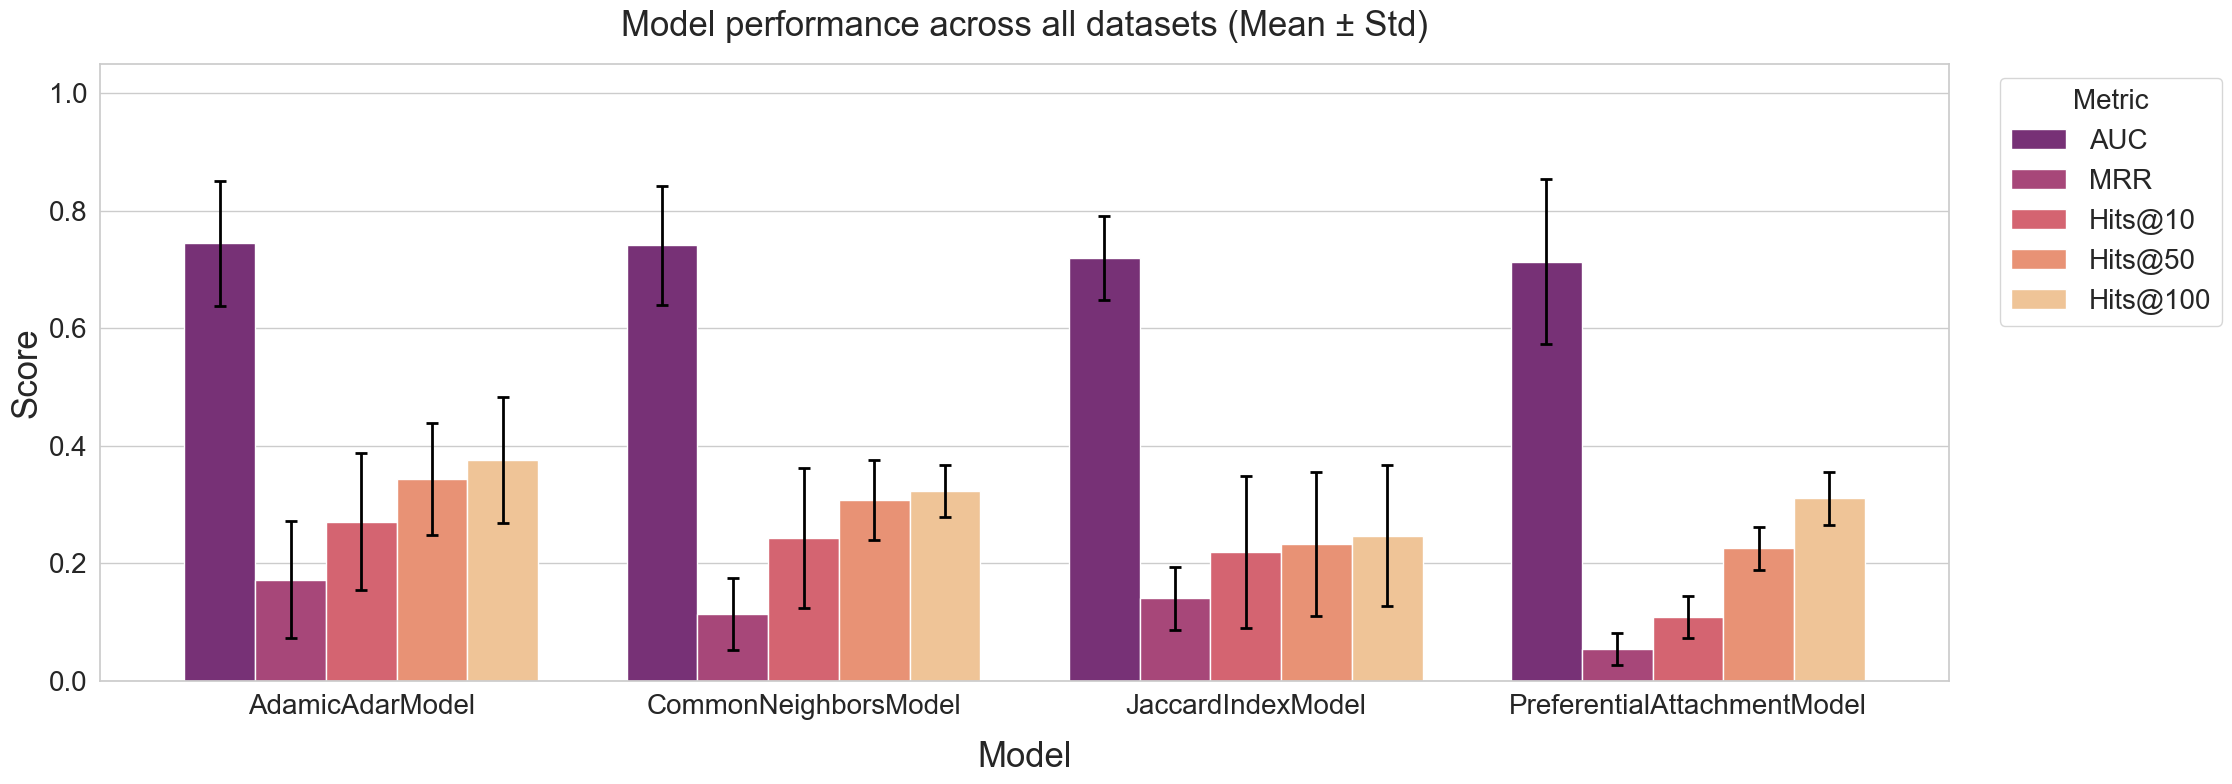


SUMMARY STATISTICS: Model performance across all datasets


,model_name,AUC_mean,AUC_var,MRR_mean,MRR_var,Hits@10_mean,Hits@10_var,Hits@50_mean,Hits@50_var,Hits@100_mean,Hits@100_var
0,AdamicAdarModel,0.7446,0.0112,0.1726,0.0099,0.2710,0.0137,0.3439,0.0090,0.3764,0.0115
1,CommonNeighborsModel,0.7413,0.0103,0.1144,0.0038,0.2430,0.0143,0.3079,0.0047,0.3234,0.0019
7,JaccardIndexModel,0.7196,0.0050,0.1404,0.0029,0.2192,0.0169,0.2330,0.0152,0.2471,0.0145
10,PreferentialAttachmentModel,0.7134,0.0196,0.0543,0.0007,0.1085,0.0013,0.2258,0.0013,0.3105,0.0021


In [33]:
# Only heuristic models
model_filter = {
    "CommonNeighborsModel": True,
    "JaccardIndexModel": True,
    "AdamicAdarModel": True,
    "PreferentialAttachmentModel": True,
    "KNNModel": False,
    "LogisticRegressionModel": False,
    "DecisionTreeModel": False,
    "RandomForestModel": False,
    "GCNModel1": False,
    "GCNModel2": False,
    "GraphSAGEModel1": False,
    "GraphSAGEModel2": False,
    "SEALModel": False,
}
model_performance_stats_heuristic = plot_overall_model_metrics(model_filter=model_filter, filename='heuristic_models.png')

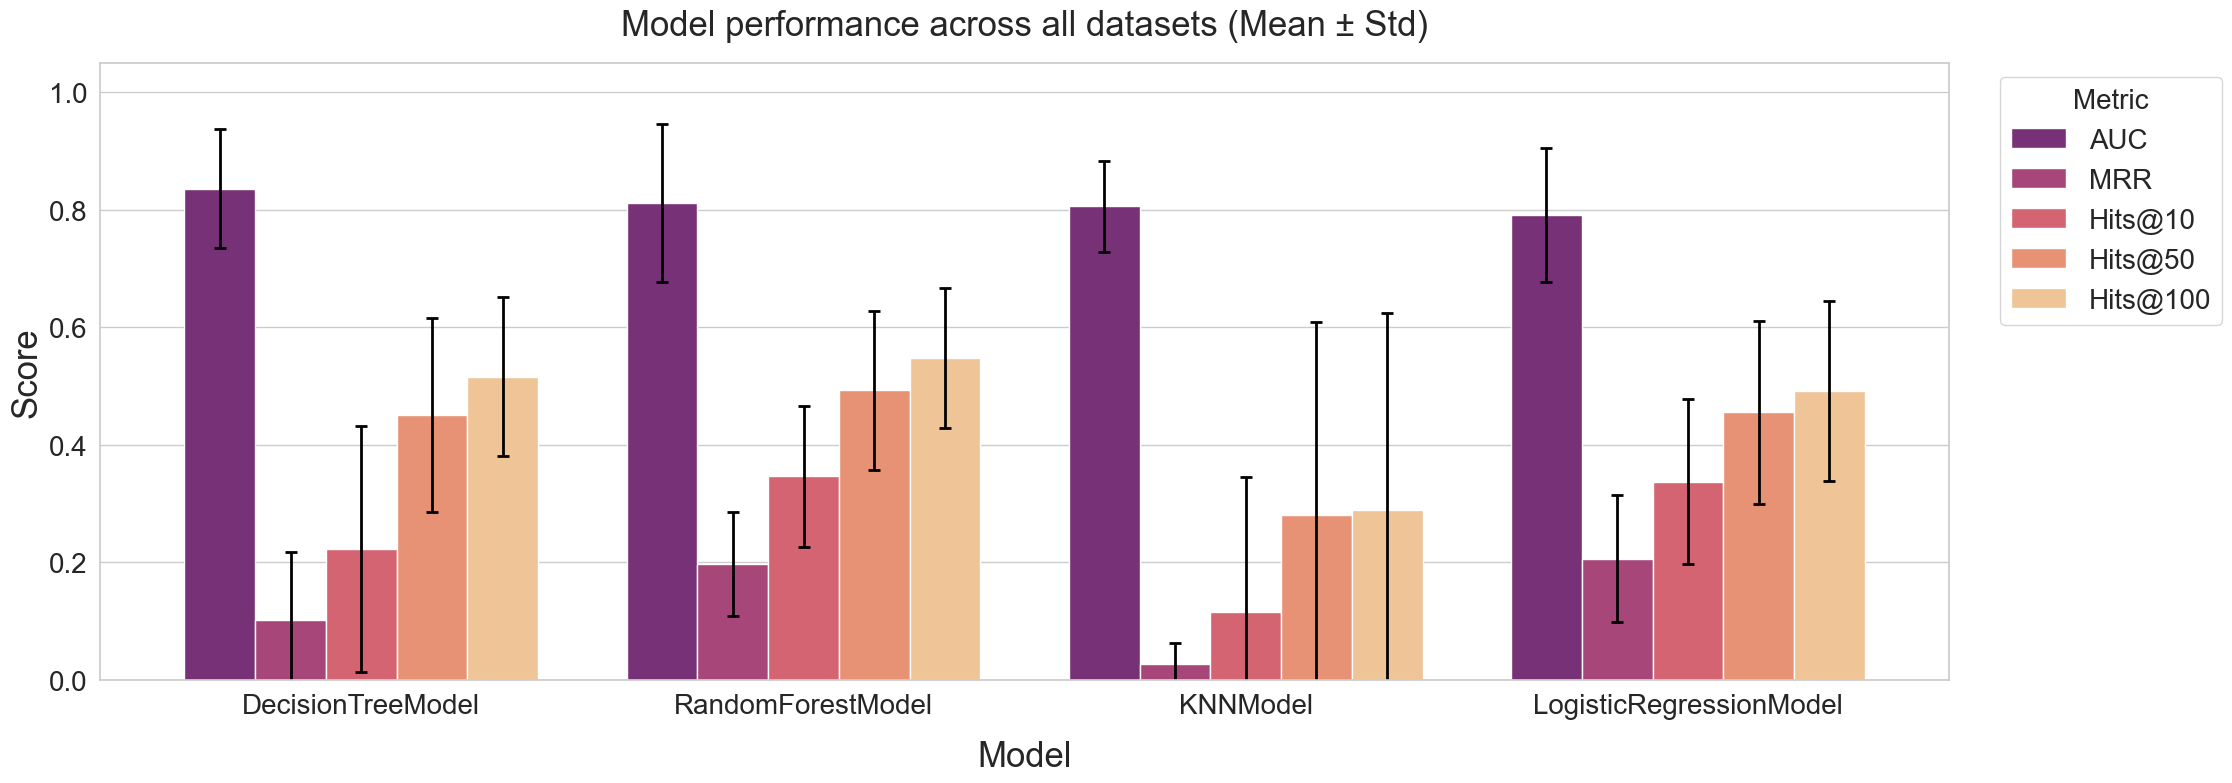


SUMMARY STATISTICS: Model performance across all datasets


,model_name,AUC_mean,AUC_var,MRR_mean,MRR_var,Hits@10_mean,Hits@10_var,Hits@50_mean,Hits@50_var,Hits@100_mean,Hits@100_var
2,DecisionTreeModel,0.8359,0.0102,0.1026,0.0130,0.2229,0.0437,0.4506,0.0273,0.5159,0.0182
11,RandomForestModel,0.8111,0.0182,0.1972,0.0077,0.3465,0.0143,0.4925,0.0184,0.5469,0.0142
8,KNNModel,0.8055,0.0061,0.0275,0.0013,0.1151,0.0530,0.2809,0.1075,0.2888,0.1127
9,LogisticRegressionModel,0.7912,0.0130,0.2064,0.0117,0.3374,0.0196,0.4550,0.0240,0.4918,0.0236


In [34]:
# only traditional ML models
model_filter = {
    "CommonNeighborsModel": False,
    "JaccardIndexModel": False,
    "AdamicAdarModel": False,
    "PreferentialAttachmentModel": False,
    "KNNModel": True,
    "LogisticRegressionModel": True,
    "DecisionTreeModel": True,
    "RandomForestModel": True,
    "GCNModel1": False,
    "GCNModel2": False,
    "GraphSAGEModel1": False,
    "GraphSAGEModel2": False,
    "SEALModel": False,
}
model_performance_stats_traditional_ml = plot_overall_model_metrics(model_filter=model_filter, filename='traditional_ml_models.png')

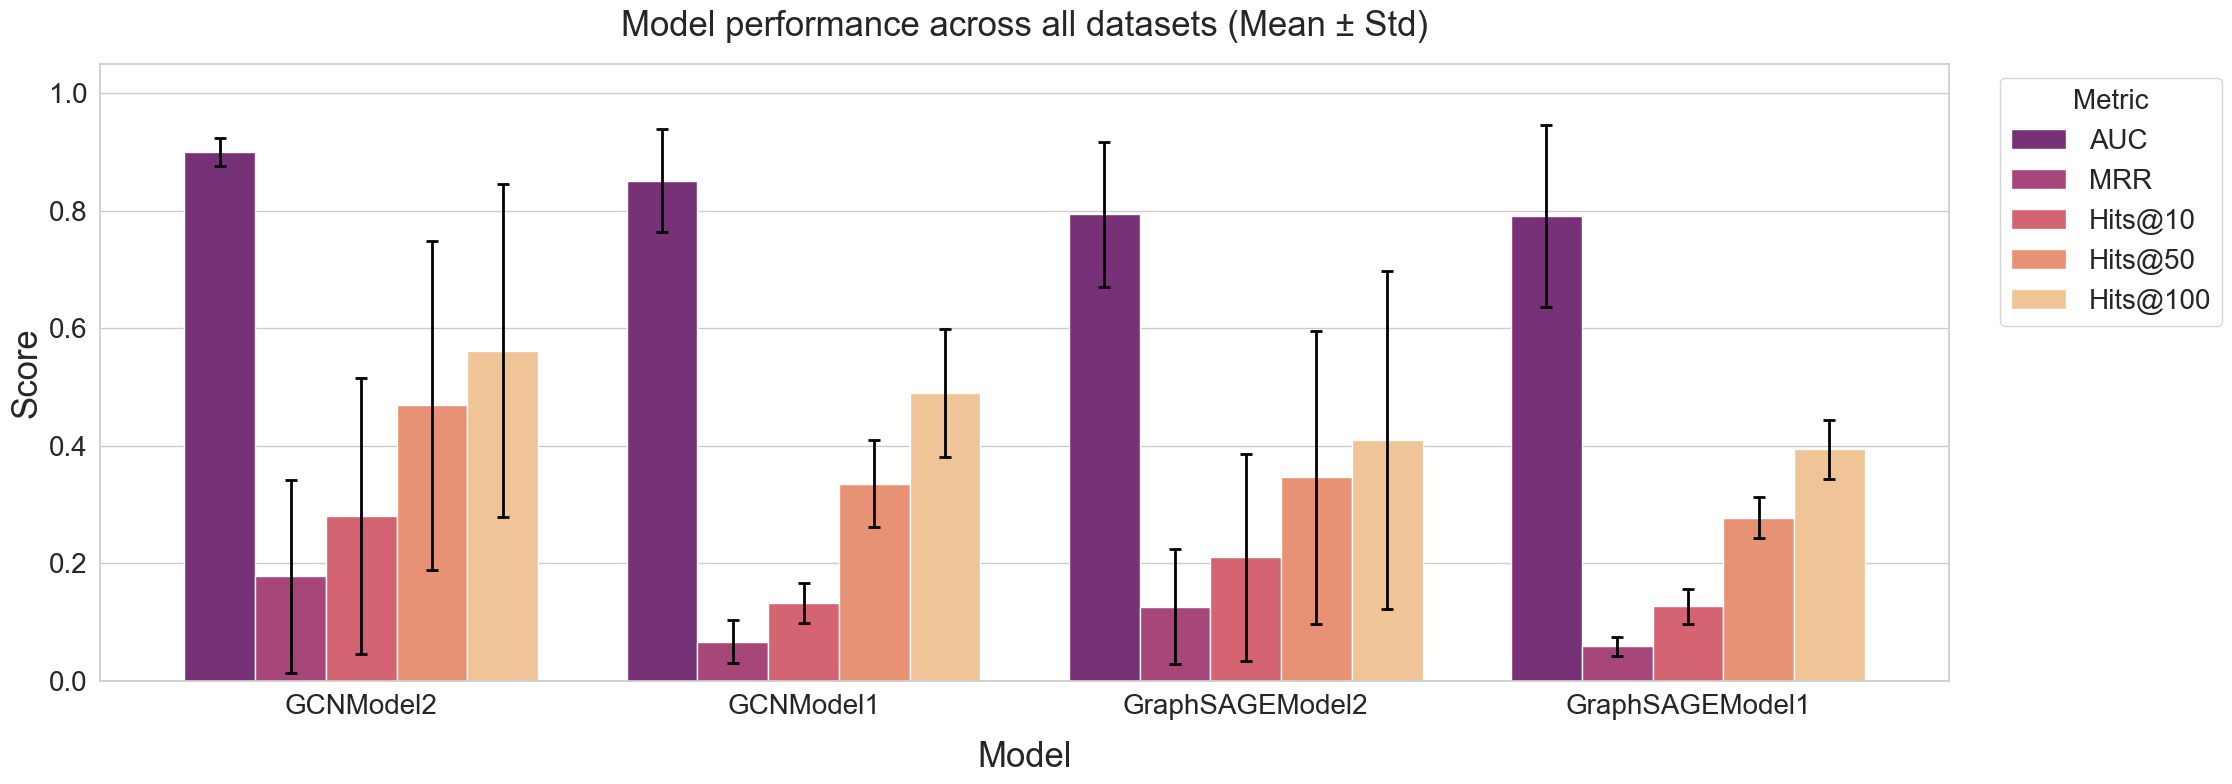


SUMMARY STATISTICS: Model performance across all datasets


,model_name,AUC_mean,AUC_var,MRR_mean,MRR_var,Hits@10_mean,Hits@10_var,Hits@50_mean,Hits@50_var,Hits@100_mean,Hits@100_var
4,GCNModel2,0.9003,0.0006,0.1779,0.0271,0.2804,0.0554,0.4691,0.0784,0.5619,0.0802
3,GCNModel1,0.8514,0.0077,0.0668,0.0014,0.1320,0.0011,0.3357,0.0055,0.4900,0.0118
6,GraphSAGEModel2,0.7936,0.0150,0.1264,0.0097,0.2102,0.0311,0.3468,0.0622,0.4107,0.0826
5,GraphSAGEModel1,0.7908,0.0240,0.0588,0.0002,0.1267,0.0009,0.2777,0.0012,0.3941,0.0025


In [35]:
# Only GNNs
model_filter = {
    "CommonNeighborsModel": False,
    "JaccardIndexModel": False,
    "AdamicAdarModel": False,
    "PreferentialAttachmentModel": False,
    "KNNModel": False,
    "LogisticRegressionModel": False,
    "DecisionTreeModel": False,
    "RandomForestModel": False,
    "GCNModel1": True,
    "GCNModel2": True,
    "GraphSAGEModel1": True,
    "GraphSAGEModel2": True,
    "SEALModel": False,
}
model_performance_stats_gnn = plot_overall_model_metrics(model_filter=model_filter, filename='gnn_models.png')

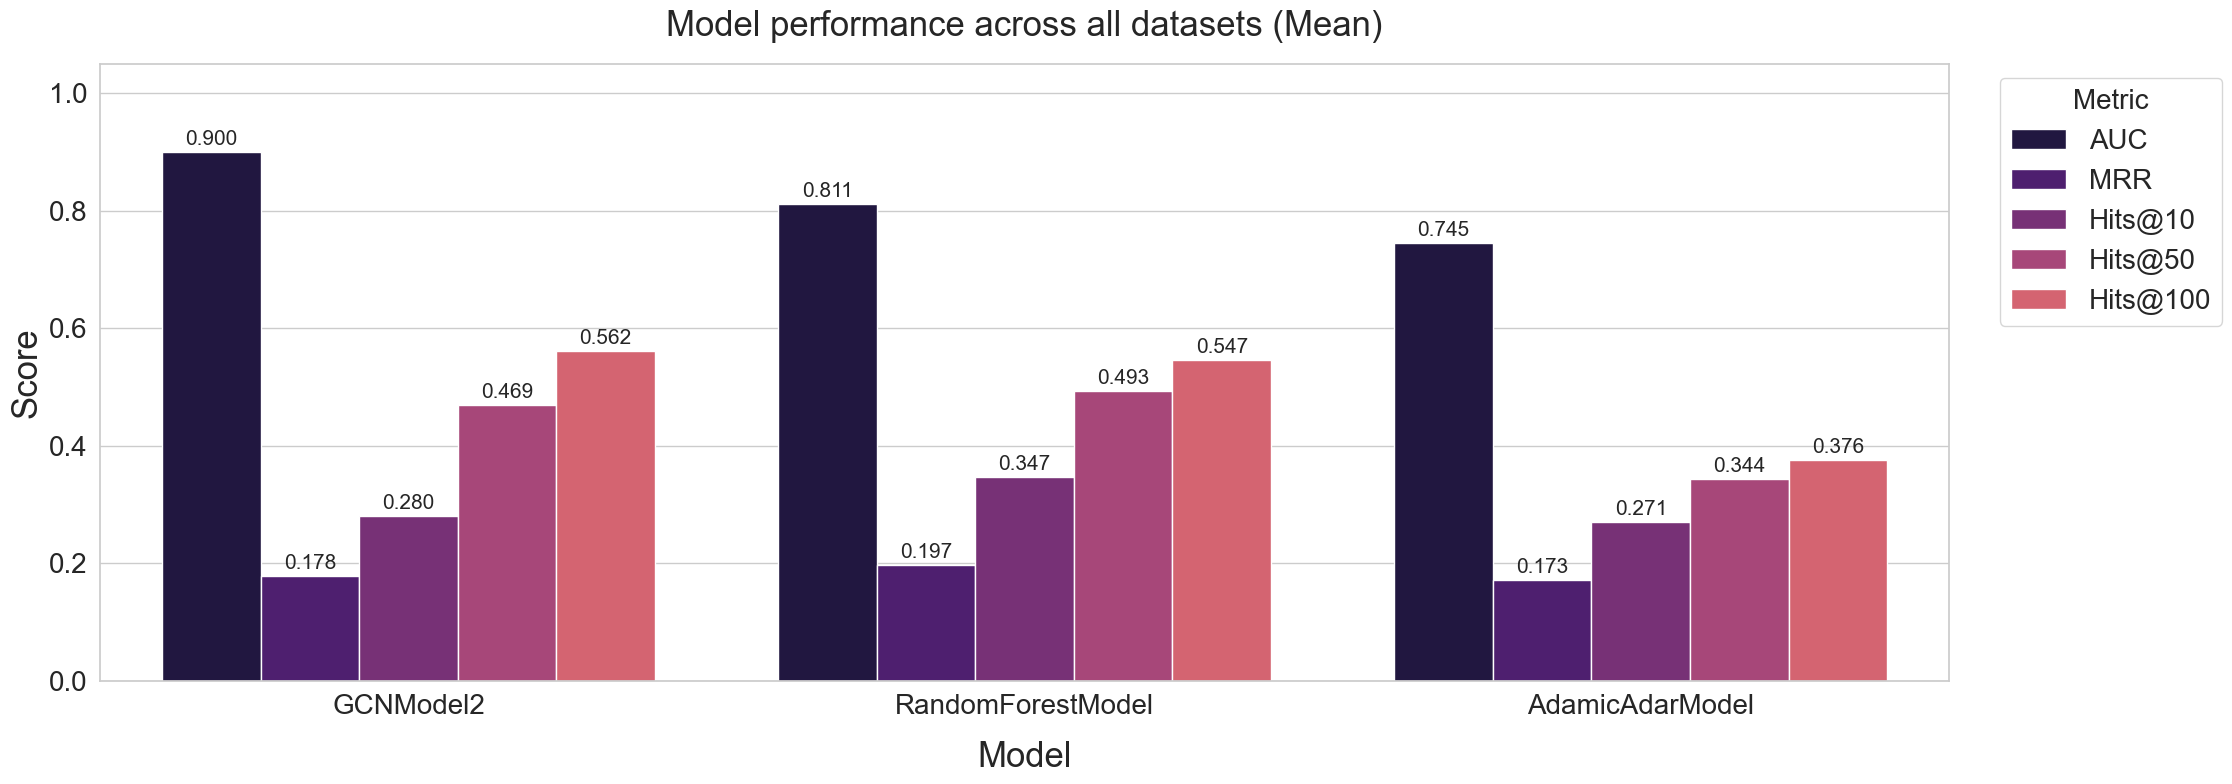


SUMMARY STATISTICS: Model performance across all datasets


,model_name,AUC_mean,AUC_var,MRR_mean,MRR_var,Hits@10_mean,Hits@10_var,Hits@50_mean,Hits@50_var,Hits@100_mean,Hits@100_var
4,GCNModel2,0.9003,0.0006,0.1779,0.0271,0.2804,0.0554,0.4691,0.0784,0.5619,0.0802
11,RandomForestModel,0.8111,0.0182,0.1972,0.0077,0.3465,0.0143,0.4925,0.0184,0.5469,0.0142
0,AdamicAdarModel,0.7446,0.0112,0.1726,0.0099,0.2710,0.0137,0.3439,0.0090,0.3764,0.0115


In [22]:
# Only the best models of each type
model_filter = {
    "CommonNeighborsModel": False,
    "JaccardIndexModel": False,
    "AdamicAdarModel": True,
    "PreferentialAttachmentModel": False,
    "KNNModel": False,
    "LogisticRegressionModel": False,
    "DecisionTreeModel": False,
    "RandomForestModel": True,
    "GCNModel1": False,
    "GCNModel2": True,
    "GraphSAGEModel1": False,
    "GraphSAGEModel2": False,
    "SEALModel": False,
}
model_performance_stats_best = plot_overall_model_metrics(model_filter=model_filter, filename='best_models.png', show_values=True, show_variance=False)

# Role Discovery: Result Analysis

The primary objective is to compare the efficacy of two distinct approaches:

1.  **Traditional Method (`Feature-Based_Roles`)**: This method involves extracting a vector of structural features (e.g., centrality metrics, clustering coefficient) for each node and then applying K-Means clustering.
2.  **GNNs with Simple Features**: Unsupervised GNNs (`GAE`, `DGI`) learn node embeddings from the graph structure, using only node degrees as initial features.
3.  **GNNs with Graphlet Features**: The same GNNs are provided with pre-computed graphlet features as input, combining engineered features with learned representations.

The analysis is performed on three datasets: **Cora**, **Actor**, and **CLUSTER**. We will evaluate the models based on internal clustering metrics and qualitative analysis, aiming to answer the following key questions:

  - Which method produces better-separated roles (clusters)?
  - How do we determine the optimal number of roles, $k$?
  - Can we assign meaningful, interpretable labels (e.g., "hub," "bridge," "periphery") to the discovered roles?

  - How crucial are input features for graph neural networks in the context of role discovery?

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import warnings
import sys
from IPython.display import display
from torch_geometric.datasets import Planetoid
import torch
import matplotlib.ticker as mticker
import matplotlib.image as mpimg
import matplotlib.gridspec as gridspec
import networkx as nx
from torch_geometric.utils import to_networkx
from scipy.spatial.distance import cdist

project_root = str(Path().resolve().parent)
if project_root not in sys.path:
    print(f"Adding project root to path: {project_root}")
    sys.path.append(project_root)

from role_discovery.models.GNNEmbedder import GNNEmbedder
from role_discovery.models.DGIEmbedder import DGIEmbedder
from role_discovery.models.FeatureBasedRoles import FeatureBasedRoles
from role_discovery.models.FeatureBasedRolesGraphlets import FeatureBasedRolesGraphlets
from role_discovery.models.GNNEmbedderGraphlets import GNNEmbedderGraphlets
from role_discovery.models.DGIEmbedderGraphlets import DGIEmbedderGraphlets
from role_discovery.utils.experiment_utils import clean_params

MODELS_TO_CLASSES = {
    "Feature-Based_Roles": FeatureBasedRoles,
    "Feature-Based_Roles_Graphlets": FeatureBasedRolesGraphlets,
    "GNN_Embedder_GAE": GNNEmbedder,
    "GNN_Embedder_GAE_Graphlets": GNNEmbedderGraphlets,
    "GNN_Embedder_DGI": DGIEmbedder,
    "GNN_Embedder_DGI_Graphlets": DGIEmbedderGraphlets
}

Adding project root to path: /home/adriano/Desktop/network-science/project


In [2]:
warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style="whitegrid", palette="magma")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12

RESULTS_DIR = Path("results/role_discovery/")
DATASETS = ['Cora', 'Actor', 'CLUSTER']
MODELS = [
    "Feature-Based_Roles", "Feature-Based_Roles_Graphlets",
    "GNN_Embedder_GAE", "GNN_Embedder_GAE_Graphlets",
    "GNN_Embedder_DGI", "GNN_Embedder_DGI_Graphlets"
]

print(f"Analysis Notebook Setup Complete.")
print(f"Results Directory: {RESULTS_DIR.resolve()}")
print(f"Datasets to Analyze: {DATASETS}")


Analysis Notebook Setup Complete.
Results Directory: /home/adriano/Desktop/network-science/project/role_discovery/results/role_discovery
Datasets to Analyze: ['Cora', 'Actor', 'CLUSTER']


## 1\. High-Level Comparison Across All Datasets


In [ ]:
summary_path = RESULTS_DIR / "comparison_summary.csv"
if not summary_path.exists():
    print(f"Error: The summary file was not found at {summary_path}")
    print("Please run `python -m project.role_discovery.generate_report` first.")
    summary_df = pd.DataFrame()
else:
    summary_df = pd.read_csv(summary_path)

print(" Overall Model Performance (based on best Silhouette Score) ")
if not summary_df.empty:
    display(summary_df.sort_values('Silhouette Score', ascending=False).style.format({
        'Silhouette Score': '{:.4f}',
        'Davies-Bouldin Index': '{:.4f}',
        'Calinski-Harabasz Index': '{:,.2f}'
    }))


--- Overall Model Performance (based on best Silhouette Score) ---


,Dataset,Model,Best k,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
11,Actor,GNN_Embedder_DGI_Graphlets,3,0.9659,0.1635,"4,971.14"
7,Actor,Feature-Based_Roles_Graphlets,3,0.9497,0.3327,"20,701.46"
1,Cora,Feature-Based_Roles_Graphlets,3,0.9372,0.3978,"3,544.17"
10,Actor,GNN_Embedder_GAE_Graphlets,3,0.8564,0.4948,"6,488.84"
5,Cora,GNN_Embedder_DGI_Graphlets,3,0.8292,0.3968,"17,989.63"
8,Actor,GNN_Embedder_GAE,3,0.7600,0.3474,"9,031.48"
9,Actor,GNN_Embedder_DGI,3,0.6952,0.5631,"6,426.50"
4,Cora,GNN_Embedder_GAE_Graphlets,4,0.6829,0.6265,"1,588.97"
3,Cora,GNN_Embedder_DGI,3,0.6339,0.5306,"3,315.86"
2,Cora,GNN_Embedder_GAE,3,0.6053,0.5799,"4,242.17"


### 1.1. Visualizing Overall Performance

We will create a separate plot for each key metric.
  - **Silhouette Score**: Higher is better. Measures how similar a node is to its own role compared to other roles.
  - **Davies-Bouldin Index**: Lower is better. Measures the average similarity ratio of each role with its most similar one.
  - **Calinski-Harabasz Index**: Higher is better. The ratio of between-cluster dispersion to within-cluster dispersion.


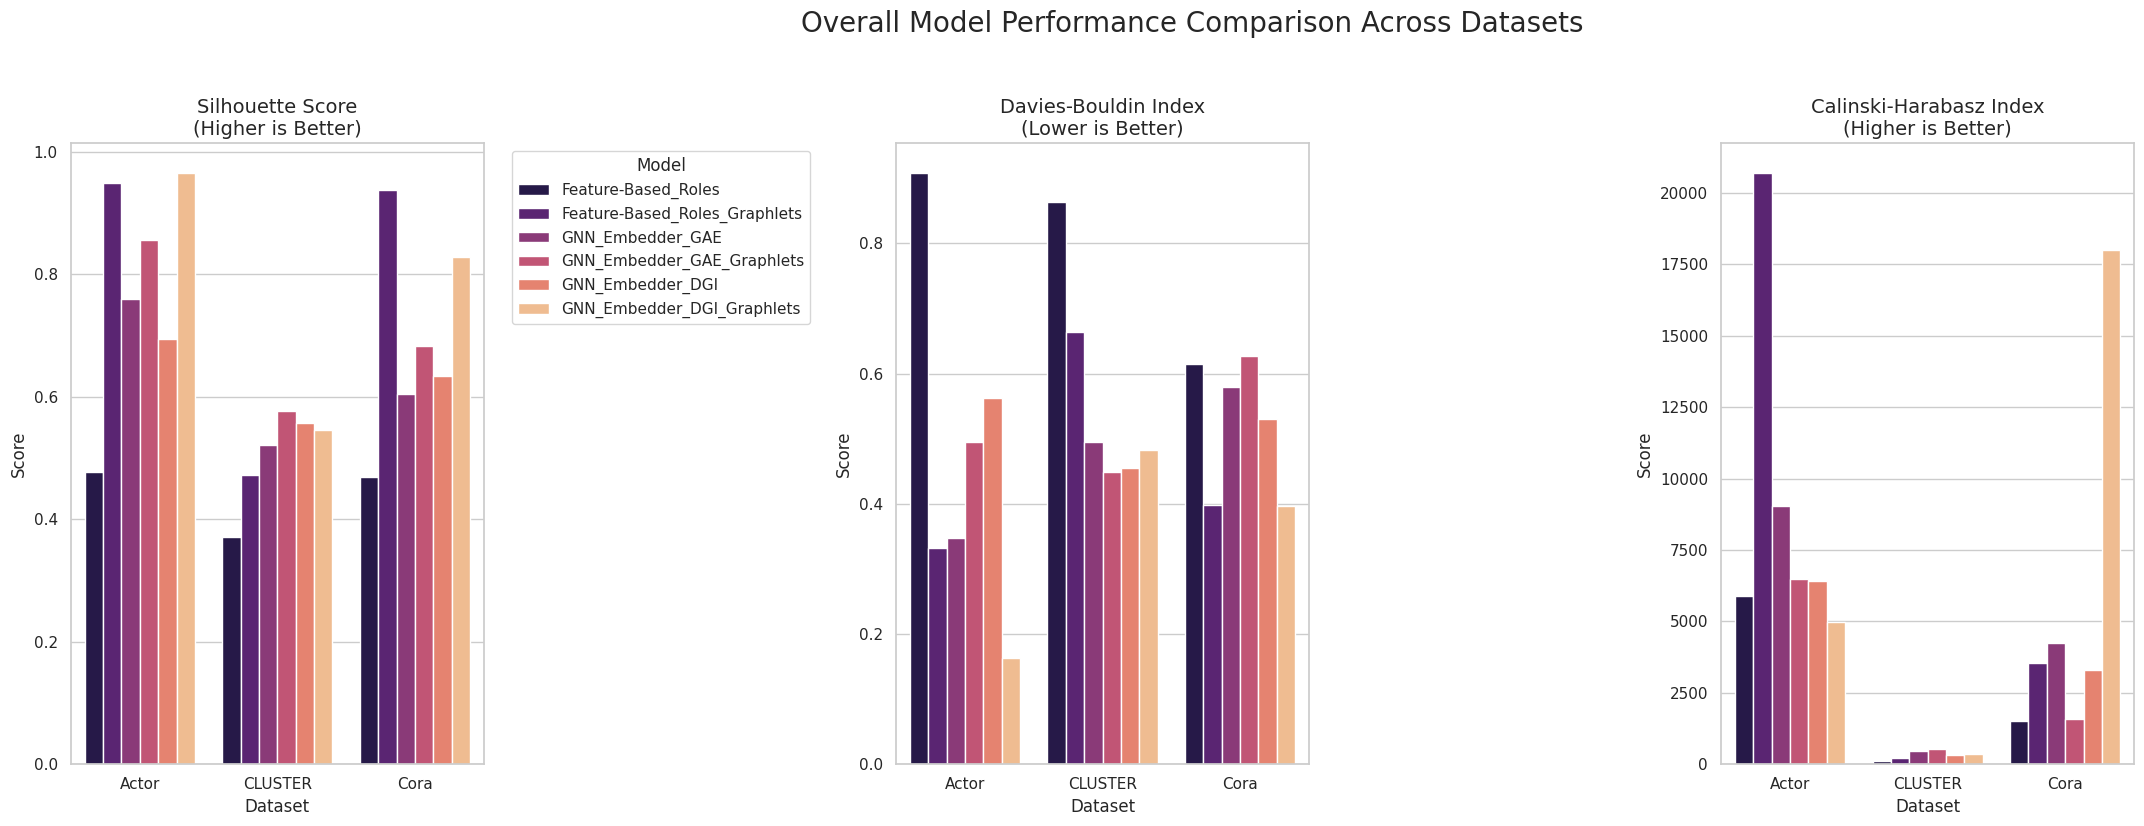

In [ ]:
if not summary_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    fig.suptitle('Overall Model Performance Comparison Across Datasets', fontsize=20, y=1.03)

    metrics = [("Silhouette Score", "Higher is Better"),
               ("Davies-Bouldin Index", "Lower is Better"),
               ("Calinski-Harabasz Index", "Higher is Better")]

    for i, (metric, interpretation) in enumerate(metrics):
        sorted_df = summary_df.sort_values(by=['Dataset', 'Silhouette Score'], ascending=[True, False])
        sns.barplot(data=sorted_df, x='Dataset', y=metric, hue='Model', ax=axes[i],
                    hue_order=MODELS) 
        axes[i].set_title(f'{metric}\n({interpretation})', fontsize=14)
        axes[i].set_xlabel("Dataset", fontsize=12)
        axes[i].set_ylabel("Score", fontsize=12)
        axes[i].tick_params(axis='x', rotation=0)
        if i == 0:
            axes[i].legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            axes[i].get_legend().remove()

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()

The charts clearly demonstrate that **graphlet-based models** (e.g., *Feature-Based\_Roles\_Graphlets* and *GNN\_Embedder\_DGI\_Graphlets*) consistently outperform others across all three metrics—**Silhouette Score** (↑), **Davies-Bouldin Index** (↓), and **Calinski-Harabasz Index** (↑). This indicates they discover roles that are both cohesive and well-separated.

Notably, models that **combine graphlet features with GNNs** show the strongest results, confirming the effectiveness of **hybrid approaches**.

Performance varies by dataset. On *CLUSTER*, models perform similarly and score lower overall.

Lastly, the baseline *Feature-Based\_Roles* method performs the worst, showing that **simple centrality features are insufficient** for capturing complex role patterns.


## 2\. Analysis of the "Cora" Dataset

Now, we perform a analysis on a single dataset to understand the results more deeply. We choose the **Cora** dataset.


### 2.1. Finding the Optimal Number of Roles ($k$)

To select the best number of roles, $k$, for each model, we plot the Silhouette Score against different values of $k$ that were tested. A peak or an "elbow" in the plot suggests an optimal value for $k$.


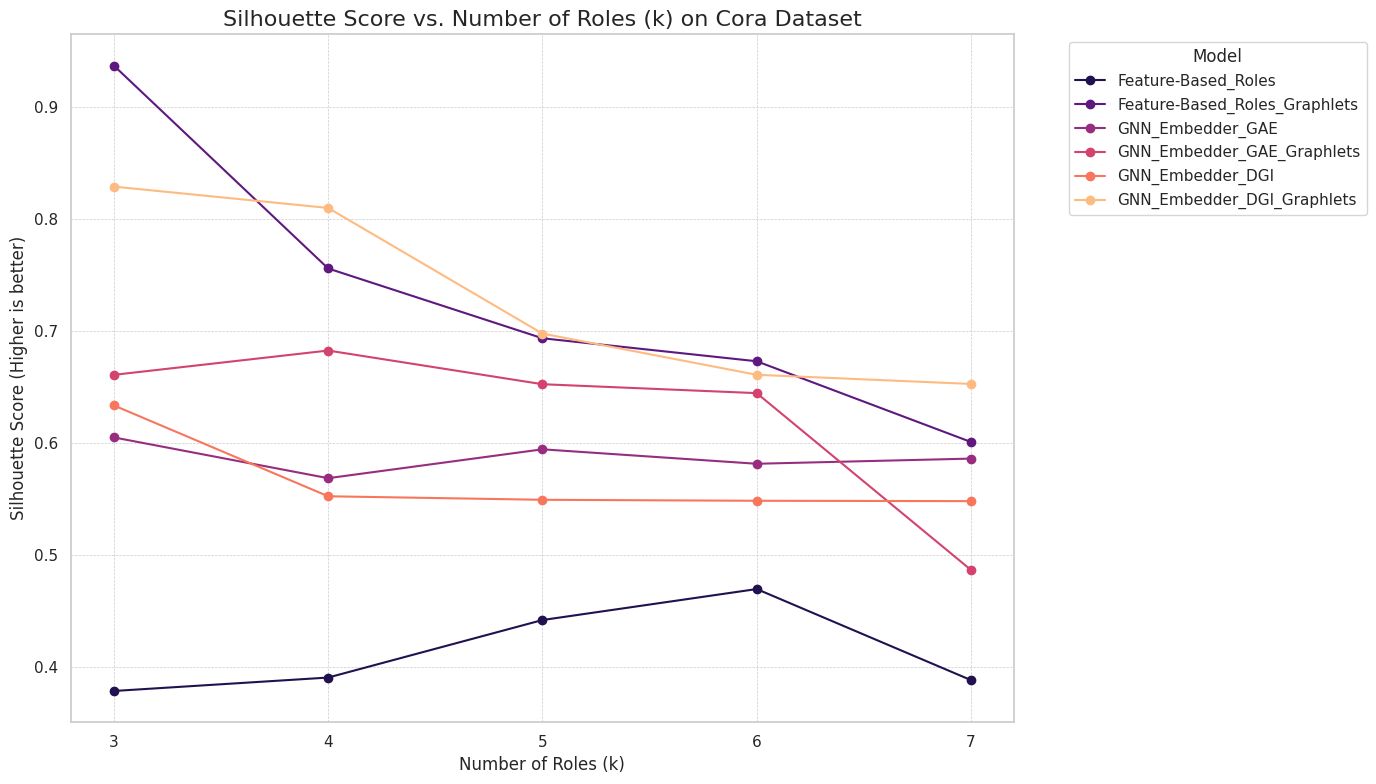

In [5]:
best_k_series = summary_df.set_index(['Dataset', 'Model'])['Best k']
cora_best_k = best_k_series.loc['Cora']

fig, ax = plt.subplots(figsize=(14, 8))

for model_name in MODELS:
    metrics_path = RESULTS_DIR / f"Cora/{model_name}_clustering_metrics.csv"
    if metrics_path.exists():
        df = pd.read_csv(metrics_path)
        ax.plot(df['k'], df['Silhouette Score'], marker='o', linestyle='-', label=model_name)

ax.set_title('Silhouette Score vs. Number of Roles (k) on Cora Dataset', fontsize=16)
ax.set_xlabel('Number of Roles (k)', fontsize=12)
ax.set_ylabel('Silhouette Score (Higher is better)', fontsize=12)
ax.set_xticks(df['k'].unique())
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

For the top-performing models `Feature-Based_Roles_Graphlets` and `GNN_Embedder_DGI_Graphlets` the Silhouette Score peaks sharply at **k=3** and then consistently declines. This indicates that forcing the data into more than three roles leads to less dense and less meaningful clusters. The drop is particularly pronounced for the `Feature-Based_Roles_Graphlets` model, which achieves an exceptionally high score at k=3 before falling off.

While some of the other models show slightly different behavior, they all achieve significantly lower scores overall, making their structural groupings less distinct. The evidence overwhelmingly suggests that **3 is the optimal number of structural roles** for the Cora network, a conclusion strongly supported by the best-performing methods.

### 2.2. Visualizing the Discovered Roles with t-SNE
t-SNE is a dimensionality reduction technique that allows us to visualize the high-dimensional node embeddings (or feature vectors) in 2D. In a good model, the nodes belonging to the same role should form distinct, well-separated visual clusters.

We will load and display the pre-generated t-SNE plots for the best $k$ value of each model.


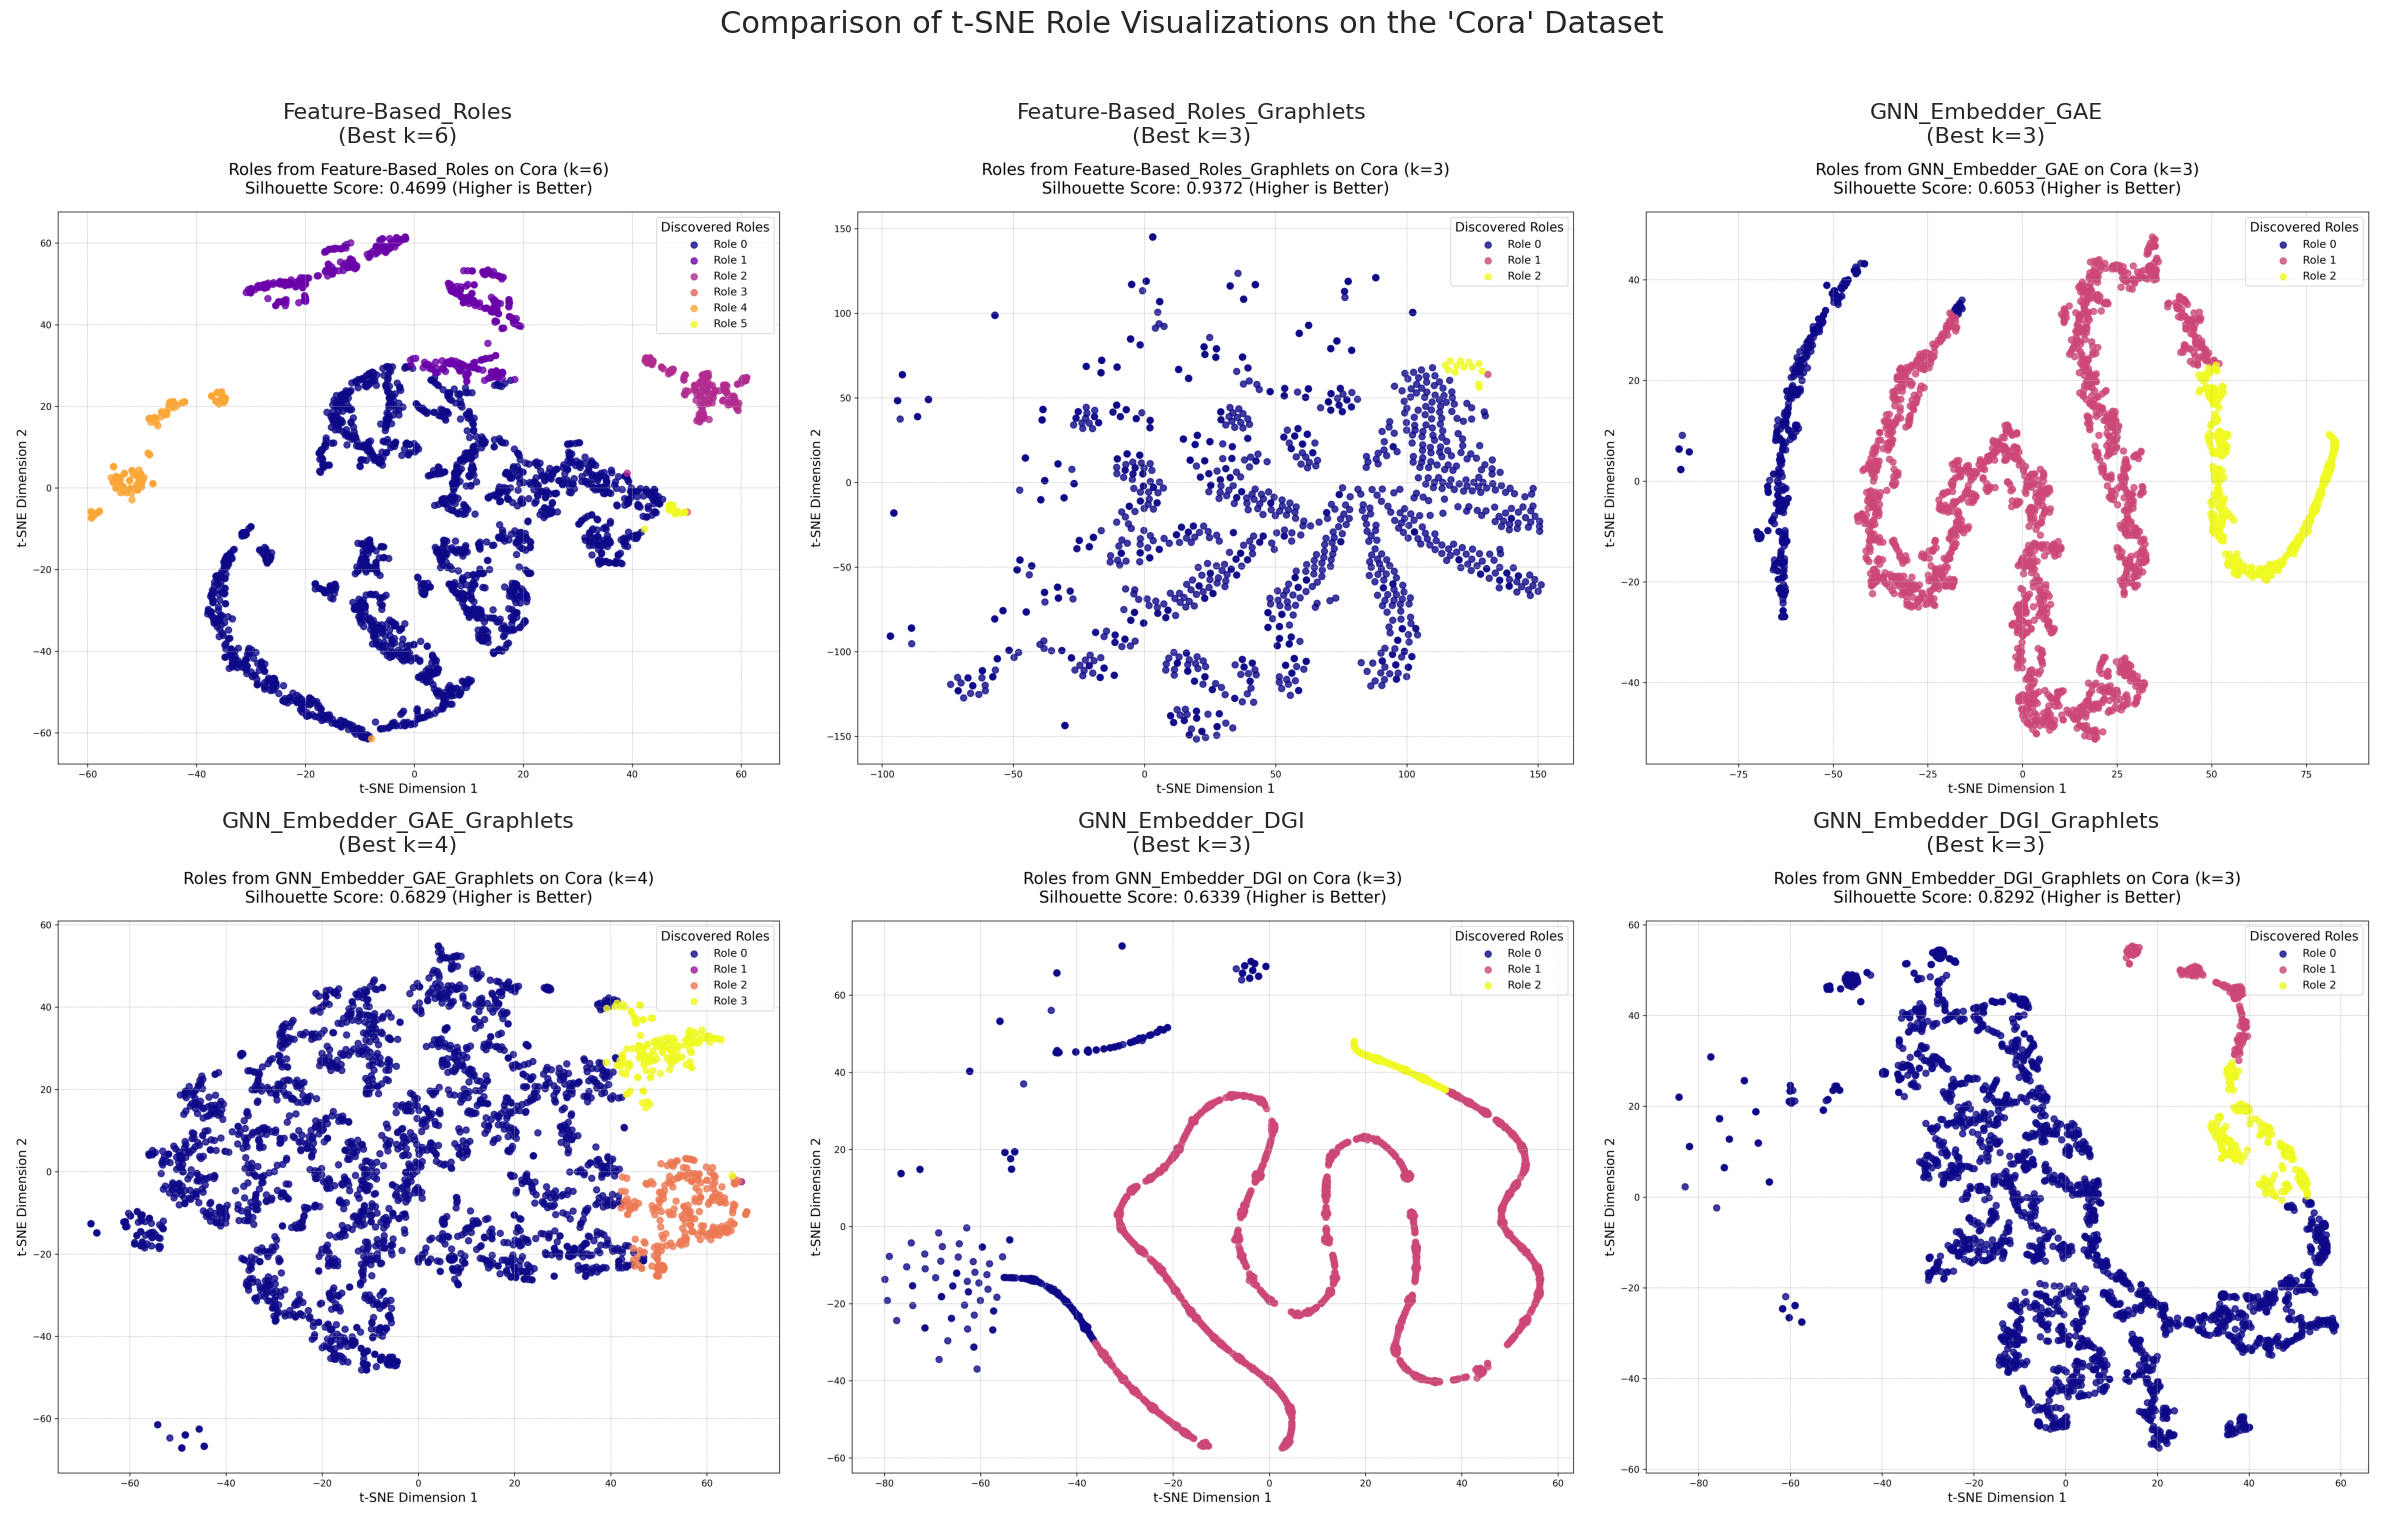

In [6]:

fig, axes = plt.subplots(2, 3, figsize=(24, 16))
axes = axes.flatten()
fig.suptitle("Comparison of t-SNE Role Visualizations on the 'Cora' Dataset", fontsize=22)

for i, model_name in enumerate(MODELS):
    ax = axes[i]
    if model_name in cora_best_k:
        k = cora_best_k[model_name]
        image_path = RESULTS_DIR / f"Cora/{model_name}_k{k}_tsne.png"
        ax.set_title(f"{model_name}\n(Best k={k})", fontsize=16, pad=10)
        
        if image_path.exists():
            img = mpimg.imread(image_path)
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, 'Image not found', ha='center', va='center', fontsize=12)
    else:
        ax.set_visible(False)
    ax.axis('off')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

These t-SNE plots provide a visual confirmation of the quantitative results from the previous step. 

* **Excellent Separation (Graphlet-Based Models):** The two models using graphlet features, `Feature-Based_Roles_Graphlets` and `GNN_Embedder_DGI_Graphlets`, show clean visualizations.
    * The `Feature-Based_Roles_Graphlets` model (top-middle) produces a distinct plot with a large central "starburst" role and two other roles that are perfectly isolated.
    * Similarly, the `GNN_Embedder_DGI_Graphlets` (bottom-right) identifies a large, dense primary role and two smaller, well-separated satellite roles.
    * This visual directly corresponds to their high Silhouette scores and strongly suggests they have uncovered a meaningful core-periphery structure in the network.

* **Poor Separation (Baseline Model):** The `Feature-Based_Roles` model (top-left), which had the lowest scores, shows exactly what we would expect heavily intermingled and poorly defined clusters. It is visually difficult to distinguish between the different roles, confirming that the standard centrality features were insufficient for this task on the Cora dataset.

### 2.3. Interpreting Role Characteristics
Moving beyond scores and visualizations to understand *what these roles represent*. We load the analysis files, which contain the average structural properties (degree, betweenness, etc.) for nodes within each role. By examining these properties, we can assign intuitive labels.

In [7]:
def plot_role_profiles(df, dataset_name, model_name, k, ax):
    metrics_to_plot = ['avg_degree', 'avg_betweenness', 'avg_closeness', 'avg_eigenvector', 'avg_clustering_coeff']
    profiles = df[metrics_to_plot]

    min_vals = profiles.min()
    range_vals = profiles.max() - min_vals
    range_vals[range_vals == 0] = 1.0
    profiles_normalized = (profiles - min_vals) / range_vals
    profiles_normalized = profiles_normalized.fillna(0)

    labels = ['Degree', 'Betweenness', 'Closeness', 'Eigenvector', 'Clustering Coeff.']
    num_vars = len(labels)

    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    cmap = plt.get_cmap('plasma')
    colors = cmap(np.linspace(0, 1, len(df)))

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_rlabel_position(0)
    ax.set_xticks(angles[:-1], labels, size=11)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8"], color="grey", size=9)

    for i, row in profiles_normalized.iterrows():
        values = row.values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, color=colors[i], linewidth=2.5, linestyle='solid', label=f"Role {df.at[i, 'role_id']}")
        ax.fill(angles, values, color=colors[i], alpha=0.3)

    ax.legend(loc='upper right', bbox_to_anchor=(0.15, 0.15))

In [8]:
best_model_name = summary_df.loc[summary_df[summary_df['Dataset'] == 'Cora']['Silhouette Score'].idxmax()]['Model']
k = cora_best_k[best_model_name]
analysis_path = RESULTS_DIR / f"Cora/{best_model_name}_k{k}_role_analysis.csv"

embeddings, role_labels = None, None
G = None
features_df = None

if not analysis_path.exists():
    print(f"Analysis file not found for {best_model_name}. Cannot generate plots.")
else:
    print("Loading data and calculating node features for detailed violin plots...")

    role_df = pd.read_csv(analysis_path)

    dataset = Planetoid(root='/tmp/Cora', name='Cora')
    data = dataset[0]

    ModelClass = MODELS_TO_CLASSES.get(best_model_name)
    model_instance = ModelClass()
    embeddings, role_labels = model_instance.predict(data, k=k)

    G = to_networkx(data, to_undirected=True)
    print("Calculating centrality metrics... (This may take a moment)")
    node_features_dict = {
        'degree': dict(G.degree()),
        'betweenness': nx.betweenness_centrality(G, k=int(0.2*len(G.nodes)), seed=42), 
        'closeness': nx.closeness_centrality(G),
        'eigenvector': nx.eigenvector_centrality(G, max_iter=1000, tol=1e-05),
        'clustering_coeff': nx.clustering(G)
    }
    features_df = pd.DataFrame(node_features_dict)
    features_df['role_id'] = role_labels
    display(role_df)


Loading data and calculating node features for detailed violin plots...
Initialized Feature-Based Role Discovery Model (Graphlets).
Extracting a set of node-level graphlet features (this may take a while)...
Pre-calculating triangles for all nodes...
Calculating graphlet features for each node...


Extracting Graphlet Features: 100%|██████████| 2708/2708 [00:00<00:00, 21908.33it/s]

Graphlet feature extraction complete. Matrix shape: (2708, 3)
Clustering 2708 nodes into 3 roles using KMeans...


Calculating centrality metrics... (This may take a moment)


,role_id,num_nodes,avg_degree,avg_betweenness,avg_closeness,avg_eigenvector,avg_pagerank,avg_clustering_coeff
0,0,2694,0.001356,0.001330,0.137187,0.004407,0.000353,0.241587
1,1,1,0.062061,0.235890,0.222769,0.654342,0.012207,0.011406
2,2,13,0.014237,0.032072,0.190733,0.032785,0.002778,0.068913


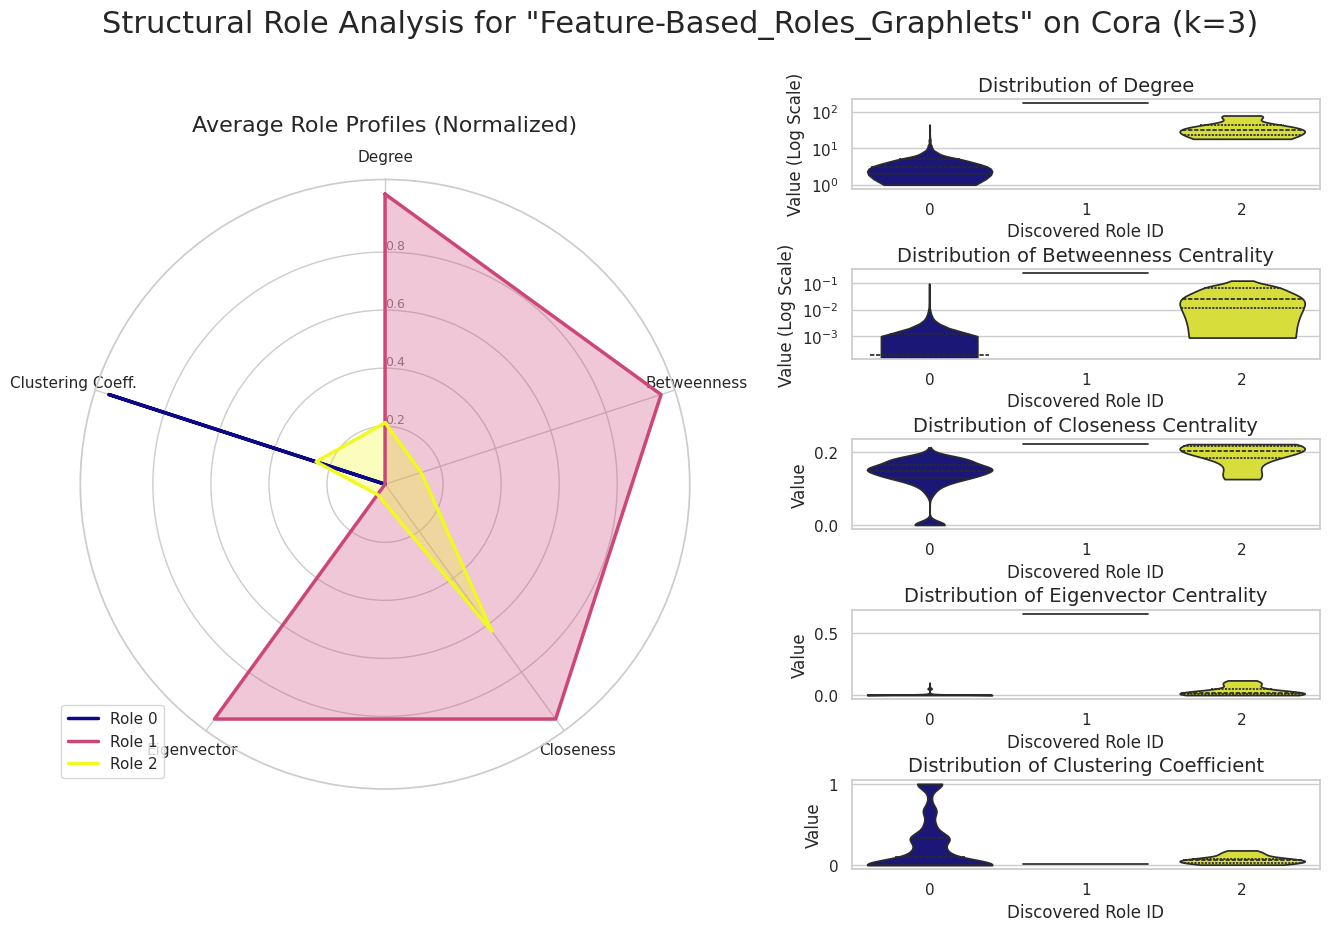

In [9]:
if analysis_path.exists():
    fig = plt.figure(figsize=(16, 10))
    gs = gridspec.GridSpec(5, 2, width_ratios=[1.3, 1], hspace=0.9, wspace=0.3)
    fig.suptitle(f'Structural Role Analysis for "{best_model_name}" on Cora (k={k})', fontsize=22, y=0.97)

    ax_radar = fig.add_subplot(gs[:, 0], polar=True)
    plot_role_profiles(role_df, "Cora", best_model_name, k, ax_radar)
    ax_radar.set_title("Average Role Profiles (Normalized)", pad=35, fontsize=16)

    metrics_to_plot = ['degree', 'betweenness', 'closeness', 'eigenvector', 'clustering_coeff']
    feature_display_names = {
        'degree': 'Degree', 'betweenness': 'Betweenness Centrality',
        'closeness': 'Closeness Centrality', 'eigenvector': 'Eigenvector Centrality',
        'clustering_coeff': 'Clustering Coefficient'
    }
    
    cmap = plt.get_cmap('plasma')
    role_colors = list(cmap(np.linspace(0, 1, k)))

    for i, metric in enumerate(metrics_to_plot):
        ax_violin = fig.add_subplot(gs[i, 1])
        sns.violinplot(data=features_df, x='role_id', y=metric, ax=ax_violin, palette=role_colors, cut=0, inner='quartile')
        ax_violin.set_title(f"Distribution of {feature_display_names[metric]}", fontsize=14)
        ax_violin.set_xlabel("Discovered Role ID", fontsize=12)
        ax_violin.set_ylabel("Value", fontsize=12)
        if metric in ['degree', 'betweenness']:
             ax_violin.set_yscale('log')
             ax_violin.set_ylabel("Value (Log Scale)", fontsize=12)


    plt.show()

The radar chart provides a structural "fingerprint" for each of the three roles discovered by the `Feature-Based_Roles_Graphlets` model on the Cora dataset. By analyzing these fingerprints and the accompanying data, we can assign them meaningful labels:

* **Role 0 (Dark Blue) - "The Periphery":** This role contains the vast majority of nodes in the network (**2,694 papers**). Its structural profile is characterized by the highest average clustering coefficient but the lowest scores on all centrality metrics (degree, betweenness, closeness, and eigenvector). This signature perfectly describes the large body of standard research papers that are part of locally dense, topically-focused clusters but have little influence on the global citation network.

* **Role 1 (Pink) - "The Global Hub":** This is a highly specialized role containing just a **single node**. This node completely dominates every centrality metric, with an exceptionally high eigenvector score, indicating it is connected to other highly influential nodes. Its extremely low clustering coefficient is the classic signature of a **hub** or **broker** that bridges many disparate parts of the network. This node likely represents a foundational or major survey paper that is cited by a wide variety of sub-fields within the dataset.

* **Role 2 (Yellow) - "The Connectors":** This is a small, elite group of **13 nodes**. They exhibit a balanced profile with moderate-to-high centrality scores across the board, significantly higher than the periphery but well below the single global hub. These nodes act as important secondary hubs or bridges, likely connecting different research areas or representing significant papers within a large sub-field.

### 2.4. Understanding Role Behavior

While role profiles reveal the *internal character* of each role, the next crucial step is to understand their behavior from two different perspectives: their statistical separation and their structural interaction. The analysis below addresses two key questions:

1.  **How well-defined are these roles?** (Left Plot)
2.  **How do they interact with each other in the network?** (Right Plot)

**On the left, the "Role Cohesion & Separation" heatmap** quantifies the quality of the roles in the feature space. It uses the average cosine distance to measure how tightly-knit each role is and how distinct it is from others.
* **Reading this plot:**  **Low values on the diagonal** signify high internal cohesion (nodes in the role are similar) while **high values off the diagonal** signify clear separation between different roles.

**On the right, the "Role Interaction Patterns" heatmap** shows the normalized proportion of a role's total links that go to other roles.
* **Reading this plot:** A high value on the diagonal indicates a **self-contained, community-like role**. High off-diagonal values reveal a **connector or satellite role** whose primary function is to link to others.


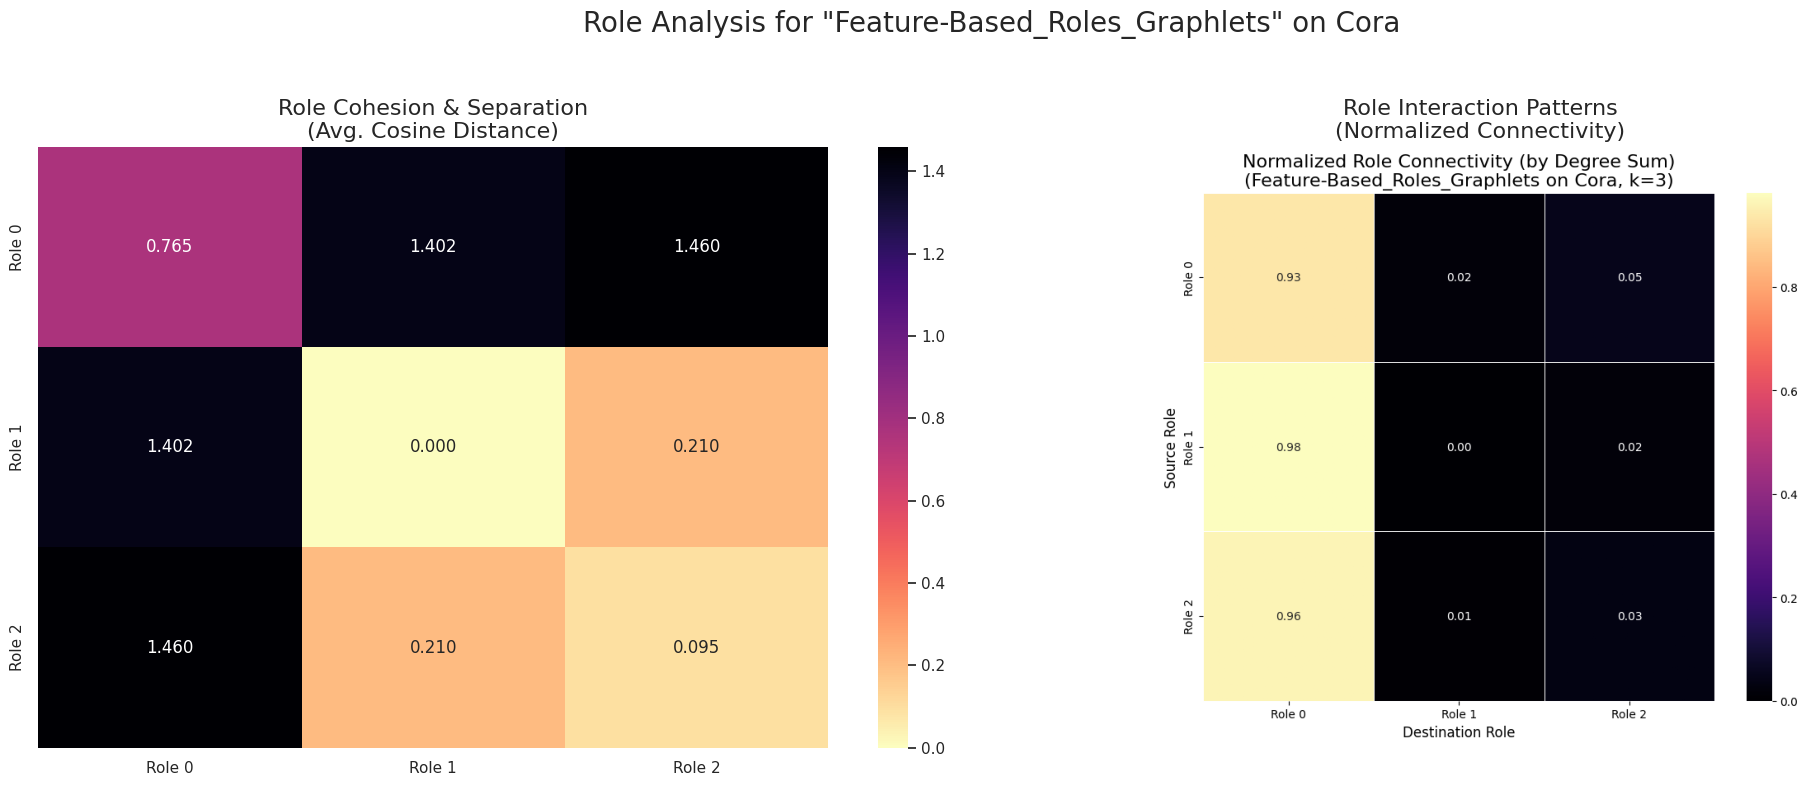

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(f'Role Analysis for "{best_model_name}" on Cora', fontsize=20)

# Plot 1: Cosine Distance Heatmap (Left)
if embeddings is not None and role_labels is not None:
    k = len(np.unique(role_labels))
    distance_matrix = np.zeros((k, k))
    
    embeddings_np = embeddings.cpu().numpy()
    role_labels_np = role_labels.cpu().numpy()

    for i in range(k):
        for j in range(i, k):
            nodes_i = embeddings_np[role_labels_np == i]
            nodes_j = embeddings_np[role_labels_np == j]
            
            if nodes_i.shape[0] > 0 and nodes_j.shape[0] > 0:
                pairwise_dists = cdist(nodes_i, nodes_j, 'cosine')
                mean_dist = np.mean(pairwise_dists)
                distance_matrix[i, j] = mean_dist
                distance_matrix[j, i] = mean_dist

    sns.heatmap(distance_matrix, annot=True, fmt=".3f", cmap="magma_r",
                xticklabels=[f"Role {i}" for i in range(k)],
                yticklabels=[f"Role {i}" for i in range(k)],
                ax=axes[0])
    axes[0].set_title("Role Cohesion & Separation\n(Avg. Cosine Distance)", fontsize=16)

# Plot 2: Normalized Role Connectivity (Right)
model_to_plot = best_model_name
dataset_name = 'Cora'

if model_to_plot in cora_best_k:
    k = cora_best_k[model_to_plot]
    norm_path = RESULTS_DIR / f"{dataset_name}/{model_to_plot}_k{k}_role_adj_heatmap_normalized.png"
    
    axes[1].set_title("Role Interaction Patterns\n(Normalized Connectivity)", fontsize=16)
    
    if norm_path.exists():
        img_norm = mpimg.imread(norm_path)
        axes[1].imshow(img_norm)
    else:
        axes[1].text(0.5, 0.5, f'Image not found:\n{norm_path}', ha='center', va='center', wrap=True)
        
    axes[1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

* **Role 0 is the Central "Core":**
    * The **Interaction plot (right)** shows that Role 0 is highly insular, with **93%** of its connections remaining internal. This identifies it as the network's dense core.
    * The **Cohesion plot (left)** adds nuance: this large core is structurally distinct from the other roles (high distance of `1.4+`), but has some internal diversity (distance of `0.765`), as expected from a large body of mainstream papers.

* **Roles 1 & 2 are Functionally Identical "Satellites":**
    * The **Interaction plot (right)**: both Role 1 and Role 2 behave as classic satellites, directing almost all their connections (`98%` and `96%` respectively) exclusively toward the core (Role 0). They have virtually no connections to each other or within themselves.
    * The **Cohesion plot (left)** reveals that these satellite roles are extremely well-defined and internally consistent, with very low internal distances (`0.000` and `0.095`).

 We have two distinct clusters of nodes (Roles 1 and 2) that are, functionally, almost identical—their job is to connect to the core. The Cohesion plot confirms this by showing that while they are separate roles, they are structurally much more similar to each other (distance of `0.210`) than they are to the core.

## 3. Bridging Structure and Semantics

So far, our analysis has been purely structural. The `GNN_Embedder_DGI_Graphlets` model, which we identified as the top performer on real-world datasets, was trained using only the graph's structure (via graphlet features) and had no access to the actual content or subject area of the papers in the Cora dataset.

This allows us to ask a question: **Do the purely structural roles discovered by our best model correspond to distinct semantic fields?** In other words, do papers in "Neural Networks" have a different structural signature in the citation graph than papers on "Genetic Algorithms"?

Answering this will reveal the relationship between a paper's structural role (e.g., foundational paper, survey paper, niche paper) and its academic subject.


In [11]:
cora_subject_names = {
    0: 'Theory', 1: 'Reinforcement Learning', 2: 'Genetic Algorithms',
    3: 'Neural Networks', 4: 'Probabilistic Methods', 5: 'Case-Based',
    6: 'Rule-Learning'
}

dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

print("\nCell executed successfully: All modules imported.")


Cell executed successfully: All modules imported.


In [12]:
dataset_name = "Cora"
cora_summary = summary_df[summary_df['Dataset'] == dataset_name]
best_model_name = cora_summary.loc[cora_summary['Silhouette Score'].idxmax()]['Model']
print(f"The best performing model for {dataset_name} is: '{best_model_name}'")

cora_best_k_series = best_k_series.loc['Cora']
best_k = cora_best_k_series[best_model_name]

model_class_map = {
    'GNN_Embedder_GAE': GNNEmbedder,
    'GNN_Embedder_DGI': DGIEmbedder,
    'Feature-Based_Roles': FeatureBasedRoles,
    'Feature-Based_Roles_Graphlets': FeatureBasedRolesGraphlets,
    'GNN_Embedder_GAE_Graphlets': GNNEmbedderGraphlets,
    'GNN_Embedder_DGI_Graphlets': DGIEmbedderGraphlets
}

ModelClass = model_class_map.get(best_model_name)
model = None

if 'GNN' in best_model_name:
    print("Best model is a GNN. Loading hyperparameters...")
    tuning_results_path = RESULTS_DIR / dataset_name / "hyperparameter_tuning_results.csv"
    tuning_df = pd.read_csv(tuning_results_path)
    model_tuning_results = tuning_df[tuning_df['model_name'] == best_model_name]

    if not model_tuning_results.empty:
        best_model_params_raw = model_tuning_results.iloc[0].to_dict()
        params = clean_params({k: v for k, v in best_model_params_raw.items() if k not in ['model_name', 'best_silhouette', 'emb_dim', 'in_channels']})
        print(f"Loading model with k={best_k} and params: {params}")
        
        init_params = {
            **params,
            "model_path": str(RESULTS_DIR / dataset_name / f"best_{best_model_name}_model.pt"),
            "force_retrain": False
        }
        if best_model_name == 'GNN_Embedder_DGI':
            init_params['in_channels'] = data.num_features
        
        model = ModelClass(**init_params)
    else:
        print(f"ERROR: GNN model '{best_model_name}' not found in tuning results file.")

else: 
    print(f"Best model is feature-based. Instantiating '{best_model_name}' directly.")
    model = ModelClass()


The best performing model for Cora is: 'Feature-Based_Roles_Graphlets'
Best model is feature-based. Instantiating 'Feature-Based_Roles_Graphlets' directly.
Initialized Feature-Based Role Discovery Model (Graphlets).


In [ ]:
if model:
    embeddings, role_labels = model.predict(data, k=best_k)
    print(f"\nSuccessfully assigned {data.num_nodes} nodes to {best_k} roles using {best_model_name}.")

    semantic_df = pd.DataFrame({
        'role_id': role_labels.numpy(),
        'subject_id': data.y.numpy()
    })
    semantic_df['subject_name'] = semantic_df['subject_id'].map(cora_subject_names)

    crosstab = pd.crosstab(semantic_df['role_id'], semantic_df['subject_name'])
    crosstab_norm = crosstab.div(crosstab.sum(axis=1), axis=0)

    print("\n Subject Distribution within Each Structural Role ")
    display(crosstab_norm.style.format("{:.2%}"))


Extracting a set of node-level graphlet features (this may take a while)...
Pre-calculating triangles for all nodes...
Calculating graphlet features for each node...


Extracting Graphlet Features: 100%|██████████| 2708/2708 [00:00<00:00, 21807.25it/s]

Graphlet feature extraction complete. Matrix shape: (2708, 3)
Clustering 2708 nodes into 3 roles using KMeans...

Successfully assigned 2708 nodes to 3 roles using Feature-Based_Roles_Graphlets.

--- Subject Distribution within Each Structural Role ---


subject_name,Case-Based,Genetic Algorithms,Neural Networks,Probabilistic Methods,Reinforcement Learning,Rule-Learning,Theory
role_id,,,,,,,
0,11.06%,15.37%,30.18%,15.81%,7.91%,6.68%,12.99%
1,0.00%,100.00%,0.00%,0.00%,0.00%,0.00%,0.00%
2,0.00%,23.08%,38.46%,0.00%,30.77%,0.00%,7.69%


Although the GNN model was only given the network structure, the roles it discovered correspond to distinct subject distributions.

* **Role 1:** This was a remarkable discovery, consisting **100%** of papers on "Genetic Algorithms." This indicates that the citation patterns within this field are so unique that they create a distinct structural footprint that the model could perfectly isolate.

* **Role 2:** This role captured a "meta-role" of closely related AI topics, primarily grouping "Neural Networks" (38%), "Reinforcement Learning" (31%), and other related papers. The model correctly identified that these fields share a common structure in the citation network.

* **Role 0:** This larger, more diverse role represents the interdisciplinary core of the network, containing a mix of all subjects.

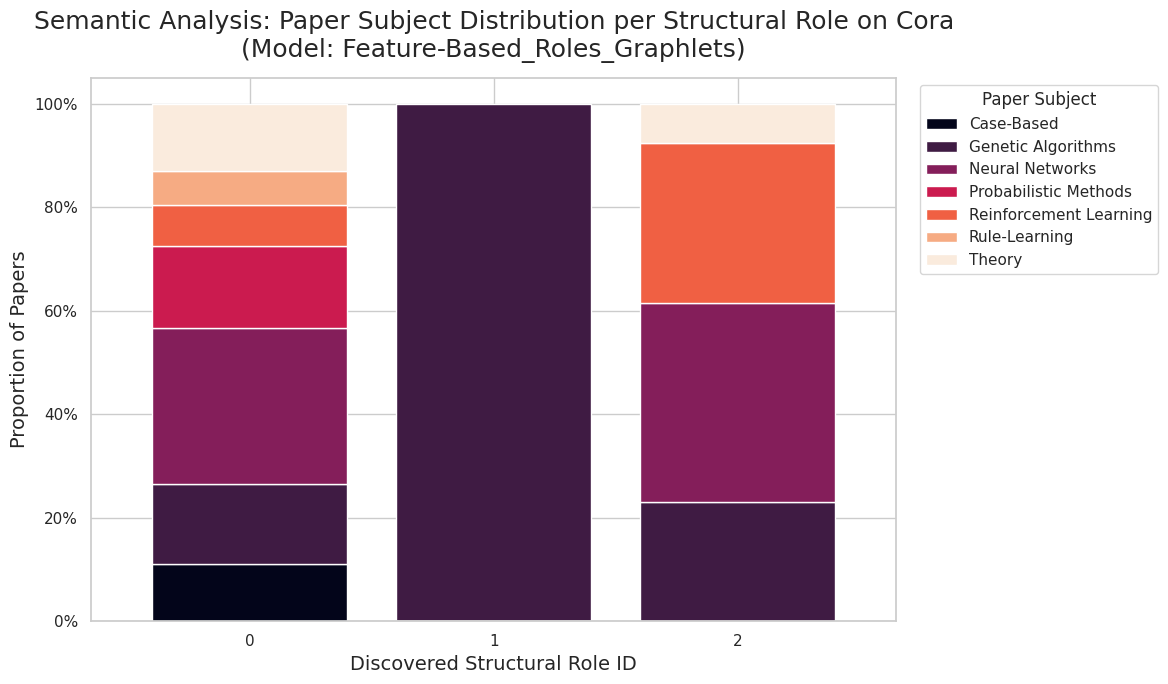

In [14]:
if model:
    fig, ax = plt.subplots(figsize=(14, 7))
    crosstab_norm.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        cmap='rocket',
        width=0.8
    )

    ax.set_title(f'Semantic Analysis: Paper Subject Distribution per Structural Role on Cora\n(Model: {best_model_name})', fontsize=18, pad=15)
    ax.set_xlabel('Discovered Structural Role ID', fontsize=14)
    ax.set_ylabel('Proportion of Papers', fontsize=14)
    ax.tick_params(axis='x', rotation=0)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0)) 
    plt.legend(title='Paper Subject', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()